# Phase 4a: Pro reference and deviation pipeline

Builds the foundation for the coaching agent. Takes any frame, classifies it (Phase 2 CNN), computes meaningful deviations from typical pro form at that position.

**Outputs:**
- `data/processed/pro_reference.json` — per-(P-position × view) statistics
- A `compute_deviation(...)` function the agent will call
- A `detect_pose_and_shaft(image_path)` function wrapping pose + shaft proxy

## 1. Setup

In [1]:
# Manual overwride of protobuf version to resolve compatibility issues with mediapipe.
import sys
!{sys.executable} -m pip uninstall protobuf -y
!{sys.executable} -m pip uninstall protobuf -y
!{sys.executable} -m pip uninstall protobuf -y
!{sys.executable} -m pip install "protobuf==4.25.5"

Found existing installation: protobuf 4.25.5
Uninstalling protobuf-4.25.5:
  Successfully uninstalled protobuf-4.25.5
Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:


ERROR: Exception:
Traceback (most recent call last):
  File "c:\python312\Lib\shutil.py", line 847, in move
    os.rename(src, real_dst)
PermissionError: [WinError 5] Adgang nægtet: 'c:\\python312\\lib\\site-packages\\google\\_upb\\' -> 'C:\\Users\\Jacob\\AppData\\Local\\Temp\\pip-uninstall-pcetmkoq'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\cli\base_command.py", line 109, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\cli\base_command.py", line 102, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\commands\uninstall.py", line 105, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File

Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:


ERROR: Exception:
Traceback (most recent call last):
  File "c:\python312\Lib\shutil.py", line 847, in move
    os.rename(src, real_dst)
PermissionError: [WinError 5] Adgang nægtet: 'c:\\python312\\lib\\site-packages\\google\\_upb\\' -> 'C:\\Users\\Jacob\\AppData\\Local\\Temp\\pip-uninstall-4wrbkzvd'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\cli\base_command.py", line 109, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\cli\base_command.py", line 102, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\pip\_internal\commands\uninstall.py", line 105, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File

Defaulting to user installation because normal site-packages is not writeable
  Using cached protobuf-4.25.5-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.5-cp310-abi3-win_amd64.whl (413 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.75.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.5 which is incompatible.
opentelemetry-proto 1.40.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.5 which is incompatible.
xai-sdk 1.12.2 requires protobuf<7,>=5.29.4, but you have protobuf 4.25.5 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
from pathlib import Path
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import mediapipe.python.solutions.pose as mp_pose
import numpy as np
import pandas as pd

PROCESSED_DIR = Path('../data/processed')
FRAMES_DIR = PROCESSED_DIR / 'frames'
RESULTS_DIR = Path('../data/results')
REFERENCE_PATH = PROCESSED_DIR / 'pro_reference.json'

EVENT_NAMES = ['Address', 'Toe-up', 'Mid-backswing', 'Top',
               'Mid-downswing', 'Impact', 'Mid-followthrough', 'Finish']
NUM_LANDMARKS = 33

LM = {
    'nose': 0,
    'left_shoulder': 11, 'right_shoulder': 12,
    'left_elbow': 13, 'right_elbow': 14,
    'left_wrist': 15, 'right_wrist': 16,
    'left_pinky': 17, 'left_index': 19, 'left_thumb': 21,
    'left_hip': 23, 'right_hip': 24,
    'left_knee': 25, 'right_knee': 26,
    'left_ankle': 27, 'right_ankle': 28,
}

df_kp = pd.read_parquet(PROCESSED_DIR / 'keypoints.parquet')
with open(PROCESSED_DIR / 'splits.json') as f:
    splits = json.load(f)

vis_cols = [f'kp_v_{i}' for i in range(NUM_LANDMARKS)]
df_kp['mean_visibility'] = df_kp[vis_cols].mean(axis=1)
df_train = df_kp[
    df_kp['clip_id'].isin(splits['train'])
    & (df_kp['mean_visibility'] >= 0.3)
].copy()
print(f'Training frames available: {len(df_train)}')

Training frames available: 1953


## 2. Pose reference: joint angle distributions per P-position × view

In [3]:
def kp_xy_from_row(row, name):
    i = LM[name]
    return np.array([row[f'kp_x_{i}'], row[f'kp_y_{i}']])


def kp_xy_from_array(kp, name):
    i = LM[name]
    return np.array([kp[i, 0], kp[i, 1]])


def angle_at(b, a, c):
    """Angle at b formed by a-b-c, in degrees [0, 180]."""
    ba = a - b
    bc = c - b
    nba = np.linalg.norm(ba)
    nbc = np.linalg.norm(bc)
    if nba < 1e-8 or nbc < 1e-8:
        return np.nan
    cos_ang = np.dot(ba, bc) / (nba * nbc)
    return float(np.degrees(np.arccos(np.clip(cos_ang, -1.0, 1.0))))


def compute_joint_angles_from_row(row):
    angles = {}
    angles['left_elbow'] = angle_at(
        kp_xy_from_row(row, 'left_elbow'),
        kp_xy_from_row(row, 'left_wrist'),
        kp_xy_from_row(row, 'left_shoulder'))
    angles['right_elbow'] = angle_at(
        kp_xy_from_row(row, 'right_elbow'),
        kp_xy_from_row(row, 'right_wrist'),
        kp_xy_from_row(row, 'right_shoulder'))
    angles['left_shoulder'] = angle_at(
        kp_xy_from_row(row, 'left_shoulder'),
        kp_xy_from_row(row, 'left_elbow'),
        kp_xy_from_row(row, 'left_hip'))
    angles['right_shoulder'] = angle_at(
        kp_xy_from_row(row, 'right_shoulder'),
        kp_xy_from_row(row, 'right_elbow'),
        kp_xy_from_row(row, 'right_hip'))
    angles['left_hip'] = angle_at(
        kp_xy_from_row(row, 'left_hip'),
        kp_xy_from_row(row, 'left_shoulder'),
        kp_xy_from_row(row, 'left_knee'))
    angles['right_hip'] = angle_at(
        kp_xy_from_row(row, 'right_hip'),
        kp_xy_from_row(row, 'right_shoulder'),
        kp_xy_from_row(row, 'right_knee'))
    angles['left_knee'] = angle_at(
        kp_xy_from_row(row, 'left_knee'),
        kp_xy_from_row(row, 'left_hip'),
        kp_xy_from_row(row, 'left_ankle'))
    angles['right_knee'] = angle_at(
        kp_xy_from_row(row, 'right_knee'),
        kp_xy_from_row(row, 'right_hip'),
        kp_xy_from_row(row, 'right_ankle'))
    sm = (kp_xy_from_row(row, 'left_shoulder') + kp_xy_from_row(row, 'right_shoulder')) / 2
    hm = (kp_xy_from_row(row, 'left_hip') + kp_xy_from_row(row, 'right_hip')) / 2
    spine_vec = sm - hm
    angles['spine_angle_from_vertical'] = float(np.degrees(
        np.arctan2(spine_vec[0], -spine_vec[1])
    ))
    hip_vec = kp_xy_from_row(row, 'right_hip') - kp_xy_from_row(row, 'left_hip')
    angles['hip_line_from_horizontal'] = float(np.degrees(np.arctan2(hip_vec[1], hip_vec[0])))
    sh_vec = kp_xy_from_row(row, 'right_shoulder') - kp_xy_from_row(row, 'left_shoulder')
    angles['shoulder_line_from_horizontal'] = float(np.degrees(np.arctan2(sh_vec[1], sh_vec[0])))
    return angles


JOINT_NAMES = [
    'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder',
    'left_hip', 'right_hip', 'left_knee', 'right_knee',
    'spine_angle_from_vertical', 'hip_line_from_horizontal',
    'shoulder_line_from_horizontal',
]

print('Computing joint angles for all training frames...')
angles_records = []
for _, row in df_train.iterrows():
    a = compute_joint_angles_from_row(row)
    a['label'] = row['label']
    a['view'] = row['view']
    angles_records.append(a)
df_angles = pd.DataFrame(angles_records)
print(f'Computed {len(df_angles)} angle records.')

pose_reference = {}
for label in EVENT_NAMES:
    pose_reference[label] = {}
    for view in ['face-on', 'down-the-line']:
        sub = df_angles[(df_angles['label'] == label) & (df_angles['view'] == view)]
        pose_reference[label][view] = {
            'n': len(sub),
            'joints': {
                joint: {
                    'median': float(sub[joint].median()),
                    'p10': float(sub[joint].quantile(0.10)),
                    'p25': float(sub[joint].quantile(0.25)),
                    'p75': float(sub[joint].quantile(0.75)),
                    'p90': float(sub[joint].quantile(0.90)),
                    'std': float(sub[joint].std()),
                } for joint in JOINT_NAMES
            }
        }

print(f'\nPose reference built for {len(pose_reference)} P-positions × 2 views.')

Computing joint angles for all training frames...
Computed 1953 angle records.

Pose reference built for 8 P-positions × 2 views.


## 3. Working approach: lead-arm shaft proxy

In [4]:
# Confidence damping based on the P-position's typical wrist hinge.
# At Top and Finish, wrist hinge is ~90° so the arm direction is roughly
# perpendicular to the actual shaft direction — proxy is geometrically wrong.
# At Address and Impact, hinge is ~0° so arm and shaft are roughly collinear.
WRIST_HINGE_FACTOR = {
    'Address': 1.0,           # hinge ~0°
    'Toe-up': 0.9,            # slight hinge
    'Mid-backswing': 0.6,     # partial hinge
    'Top': 0.3,               # full hinge — proxy unreliable
    'Mid-downswing': 0.6,     # still highly hinged
    'Impact': 1.0,            # re-aligned
    'Mid-followthrough': 0.6, # re-cocking
    'Finish': 0.3,            # full hinge — proxy unreliable
}


def compute_lead_arm_shaft_proxy(kp: np.ndarray, p_position: Optional[str] = None) -> Optional[dict]:
    """
    Estimate shaft direction from MediaPipe keypoints alone.

    Combines lead arm direction (shoulder → wrist) with hand direction
    (wrist → average of pinky/index landmarks) to better handle wrist hinge.

    If p_position is provided, the returned confidence is damped by a factor
    that reflects how much the wrist is typically hinged at that position.
    Top and Finish (full hinge) are damped to ~30% of base confidence;
    Address and Impact (no hinge) keep full confidence.
    """
    if kp[11, 2] < 0.5 or kp[15, 2] < 0.5:
        return None
    shoulder = kp[11, :2]
    wrist = kp[15, :2]
    arm_vec = wrist - shoulder
    arm_len = np.linalg.norm(arm_vec)
    if arm_len < 1e-6:
        return None

    if kp[17, 2] > 0.5 and kp[19, 2] > 0.5:
        hand_target = (kp[17, :2] + kp[19, :2]) / 2
        hand_vec = hand_target - wrist
        hand_len = np.linalg.norm(hand_vec)
        if hand_len > 1e-6:
            shaft_vec = 0.6 * (arm_vec / arm_len) + 0.4 * (hand_vec / hand_len)
            base_confidence = 0.7
        else:
            shaft_vec = arm_vec / arm_len
            base_confidence = 0.5
    else:
        shaft_vec = arm_vec / arm_len
        base_confidence = 0.5

    # Apply P-position-aware damping
    if p_position is not None and p_position in WRIST_HINGE_FACTOR:
        confidence = base_confidence * WRIST_HINGE_FACTOR[p_position]
    else:
        confidence = base_confidence

    return {
        'angle_deg': float(np.degrees(np.arctan2(shaft_vec[1], shaft_vec[0]))),
        'confidence': round(float(confidence), 2),
        'method': 'lead_arm_proxy',
    }


# Compute shaft proxy on all training frames
print('Computing lead-arm shaft proxy on all training frames...')
shaft_records = []
for _, row in df_train.iterrows():
    kp_arr = np.array([
        [row[f'kp_x_{i}'], row[f'kp_y_{i}'], row[f'kp_v_{i}']]
        for i in range(NUM_LANDMARKS)
    ])
    shaft = compute_lead_arm_shaft_proxy(kp_arr, p_position=row['label'])
    record = {'label': row['label'], 'view': row['view']}
    if shaft is None:
        record['shaft_angle'] = np.nan
    else:
        record['shaft_angle'] = shaft['angle_deg']
    shaft_records.append(record)

df_shaft = pd.DataFrame(shaft_records)
rate = df_shaft['shaft_angle'].notna().mean()
print(f'Proxy computation rate: {rate:.1%}')

# IQR widths — should be much tighter than Hough's 120-280°
print(f'\n=== Shaft-angle IQR widths (face-on) — proxy vs failed Hough ===')
for label in EVENT_NAMES:
    sub = df_shaft[(df_shaft['label'] == label) & (df_shaft['view'] == 'face-on') & df_shaft['shaft_angle'].notna()]
    if len(sub) > 5:
        p25 = sub['shaft_angle'].quantile(0.25)
        p75 = sub['shaft_angle'].quantile(0.75)
        med = sub['shaft_angle'].median()
        print(f'  {label:20s}: median={med:6.1f}°, IQR=[{p25:6.1f}, {p75:6.1f}], width={p75-p25:5.1f}°')

Computing lead-arm shaft proxy on all training frames...
Proxy computation rate: 55.0%

=== Shaft-angle IQR widths (face-on) — proxy vs failed Hough ===
  Address             : median=  95.5°, IQR=[  93.1,   97.6], width=  4.5°
  Toe-up              : median= 138.9°, IQR=[ 132.0,  146.0], width= 14.0°
  Mid-backswing       : median= 150.4°, IQR=[-176.2,  175.2], width=351.4°
  Top                 : median=-124.5°, IQR=[-138.1, -109.9], width= 28.2°
  Mid-downswing       : median=-167.5°, IQR=[-173.2,  173.9], width=347.1°
  Impact              : median=  84.3°, IQR=[  80.3,   88.2], width=  8.0°
  Mid-followthrough   : median=  32.4°, IQR=[  26.9,   39.8], width= 13.0°
  Finish              : median=-128.0°, IQR=[-139.6, -108.8], width= 30.8°


In [5]:
# Add shaft stats to the pro reference
for label in EVENT_NAMES:
    for view in ['face-on', 'down-the-line']:
        sub = df_shaft[
            (df_shaft['label'] == label)
            & (df_shaft['view'] == view)
            & df_shaft['shaft_angle'].notna()
        ]
        if len(sub) >= 5:
            pose_reference[label][view]['shaft'] = {
                'method': 'lead_arm_proxy',
                'n': len(sub),
                'angle_median': float(sub['shaft_angle'].median()),
                'angle_p10': float(sub['shaft_angle'].quantile(0.10)),
                'angle_p25': float(sub['shaft_angle'].quantile(0.25)),
                'angle_p75': float(sub['shaft_angle'].quantile(0.75)),
                'angle_p90': float(sub['shaft_angle'].quantile(0.90)),
                'angle_std': float(sub['shaft_angle'].std()),
            }
        else:
            pose_reference[label][view]['shaft'] = {
                'method': 'lead_arm_proxy', 'n': len(sub),
                'angle_median': None, 'angle_p25': None,
                'angle_p75': None, 'angle_std': None,
            }

with open(REFERENCE_PATH, 'w') as f:
    json.dump(pose_reference, f, indent=2)
print(f'Saved pro reference to {REFERENCE_PATH}')

Saved pro reference to ..\data\processed\pro_reference.json


## 4. Unified `detect_pose_and_shaft` function

In [6]:
_pose_model = mp_pose.Pose(
    static_image_mode=True, model_complexity=2,
    enable_segmentation=False, min_detection_confidence=0.5,
)


def detect_pose_and_shaft(image_path: Path, p_position: Optional[str] = None) -> dict:
    """
    Run pose extraction + lead-arm shaft proxy on a single image.
    Returns the structured dict the agent will consume.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return {'error': f'could not read image at {image_path}'}
    h, w = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pose_result = _pose_model.process(rgb)

    out = {'image_path': str(image_path), 'image_shape': (h, w)}

    if pose_result.pose_landmarks is None:
        out.update({'keypoints': None, 'pose_visibility_mean': 0.0,
                    'joint_angles': {}, 'shaft': None})
        return out

    kp = np.array([[lm.x, lm.y, lm.visibility]
                   for lm in pose_result.pose_landmarks.landmark], dtype=np.float32)
    out['keypoints'] = kp
    out['pose_visibility_mean'] = float(kp[:, 2].mean())

    def k(name):
        return kp_xy_from_array(kp, name)

    angles = {}
    angles['left_elbow'] = angle_at(k('left_elbow'), k('left_wrist'), k('left_shoulder'))
    angles['right_elbow'] = angle_at(k('right_elbow'), k('right_wrist'), k('right_shoulder'))
    angles['left_shoulder'] = angle_at(k('left_shoulder'), k('left_elbow'), k('left_hip'))
    angles['right_shoulder'] = angle_at(k('right_shoulder'), k('right_elbow'), k('right_hip'))
    angles['left_hip'] = angle_at(k('left_hip'), k('left_shoulder'), k('left_knee'))
    angles['right_hip'] = angle_at(k('right_hip'), k('right_shoulder'), k('right_knee'))
    angles['left_knee'] = angle_at(k('left_knee'), k('left_hip'), k('left_ankle'))
    angles['right_knee'] = angle_at(k('right_knee'), k('right_hip'), k('right_ankle'))
    sm = (k('left_shoulder') + k('right_shoulder')) / 2
    hm = (k('left_hip') + k('right_hip')) / 2
    spine_vec = sm - hm
    angles['spine_angle_from_vertical'] = float(np.degrees(np.arctan2(spine_vec[0], -spine_vec[1])))
    hip_vec = k('right_hip') - k('left_hip')
    angles['hip_line_from_horizontal'] = float(np.degrees(np.arctan2(hip_vec[1], hip_vec[0])))
    sh_vec = k('right_shoulder') - k('left_shoulder')
    angles['shoulder_line_from_horizontal'] = float(np.degrees(np.arctan2(sh_vec[1], sh_vec[0])))
    out['joint_angles'] = angles
    out['shaft'] = compute_lead_arm_shaft_proxy(kp, p_position=p_position)
    return out


# Smoke test
test_row = df_train.iloc[0]
result = detect_pose_and_shaft(FRAMES_DIR / test_row['frame_filename'])
print(f'Smoke test on {test_row["frame_filename"]} ({test_row["label"]}):')
print(f'  pose visibility: {result["pose_visibility_mean"]:.2f}')
print(f'  shaft proxy: {result["shaft"]}')

Smoke test on clip1399_event1.jpg (Address):
  pose visibility: 0.83
  shaft proxy: None


C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


## 5. The `compute_deviation` function

Compares a detection (from `detect_pose_and_shaft`) against the pro reference for the predicted P-position. Returns structured per-joint and per-shaft deviations the agent can present as coaching feedback.

In [7]:
# View-aware metric whitelist — only count deviations that are diagnostic in this camera view
VIEW_DIAGNOSTIC_METRICS = {
    'face-on': {
        'spine_angle_from_vertical',
        'shoulder_line_from_horizontal',
        'hip_line_from_horizontal',
        'left_knee', 'right_knee',
        'left_elbow', 'right_elbow',
    },
    'down-the-line': {
        'left_shoulder', 'right_shoulder',
        'left_hip', 'right_hip',
        'spine_angle_from_vertical',
        'shoulder_line_from_horizontal',
    },
}


def compute_deviation(detection: dict, p_position: str, view: str,
                      reference: dict = pose_reference) -> dict:
    if p_position not in reference or view not in reference[p_position]:
        return {'error': f'no reference for {p_position} / {view}'}
    ref = reference[p_position][view]
    out = {'p_position': p_position, 'view': view,
           'joint_deviations': [], 'shaft_deviation': None}

    diagnostic_metrics = VIEW_DIAGNOSTIC_METRICS.get(view, set())

    for joint, observed in detection.get('joint_angles', {}).items():
        if joint not in ref['joints'] or observed is None or np.isnan(observed):
            continue
        # Skip metrics that aren't reliably diagnostic in this view
        if joint not in diagnostic_metrics:
            continue
        rj = ref['joints'][joint]
        median = rj['median']
        p10, p25, p75, p90 = rj['p10'], rj['p25'], rj['p75'], rj['p90']
        std = max(rj['std'], 1.0)

        if p10 <= observed <= p90:
            # Within the broad pro range — natural variation, don't flag
            severity = 'within_typical_range'
            deviation = 0.0
        else:
            # Genuinely outside p10-p90 → real deviation
            deviation = observed - p10 if observed < p10 else observed - p90
            n_stds = abs(observed - median) / std
            severity = 'mild' if n_stds < 2.0 else 'notable'

        out['joint_deviations'].append({
            'joint': joint,
            'observed': round(observed, 1),
            'p25': round(p25, 1), 'p75': round(p75, 1),
            'p10': round(p10, 1), 'p90': round(p90, 1),
            'median': round(median, 1),
            'deviation': round(deviation, 1),
            'severity': severity,
        })

    shaft_ref = ref.get('shaft')
    if (detection.get('shaft') is not None
            and shaft_ref is not None
            and shaft_ref.get('angle_median') is not None):
        observed = detection['shaft']['angle_deg']
        p10 = shaft_ref.get('angle_p10', shaft_ref['angle_p25'])
        p25 = shaft_ref['angle_p25']
        p75 = shaft_ref['angle_p75']
        p90 = shaft_ref.get('angle_p90', shaft_ref['angle_p75'])
        median = shaft_ref['angle_median']
        proxy_confidence = detection['shaft'].get('confidence', 0.5)

        if p10 <= observed <= p90:
            severity = 'within_typical_range'
            deviation = 0.0
        else:
            deviation = observed - p10 if observed < p10 else observed - p90
            severity = 'mild' if abs(deviation) < 25 else 'notable'

        out['shaft_deviation'] = {
            'observed': round(observed, 1),
            'p10': round(p10, 1), 'p90': round(p90, 1),
            'p25': round(p25, 1), 'p75': round(p75, 1),
            'median': round(median, 1),
            'deviation': round(deviation, 1),
            'severity': severity,
            'method': 'lead_arm_proxy',
            'proxy_confidence': round(proxy_confidence, 2),
            'note': 'shaft direction estimated from lead-arm pose, not directly detected',
        }

    severities = [d['severity'] for d in out['joint_deviations']]
    if out['shaft_deviation']:
        severities.append(out['shaft_deviation']['severity'])
    if 'notable' in severities:
        out['overall_severity'] = 'notable'
    elif 'mild' in severities:
        out['overall_severity'] = 'mild'
    else:
        out['overall_severity'] = 'good'
    return out


deviation = compute_deviation(result, p_position=test_row['label'], view=test_row['view'])
print(f'Deviation for {test_row["label"]} ({test_row["view"]}):')
print(f'  overall: {deviation["overall_severity"]}')
for d in deviation['joint_deviations'][:5]:
    print(f'  {d}')
print(f'  shaft: {deviation["shaft_deviation"]}')

Deviation for Address (down-the-line):
  overall: mild
  {'joint': 'left_shoulder', 'observed': 1.6, 'p25': 22.1, 'p75': 30.5, 'p10': 14.3, 'p90': 36.6, 'median': 25.6, 'deviation': -12.7, 'severity': 'mild'}
  {'joint': 'right_shoulder', 'observed': 26.5, 'p25': 31.0, 'p75': 38.4, 'p10': 28.5, 'p90': 42.0, 'median': 34.5, 'deviation': -2.0, 'severity': 'mild'}
  {'joint': 'left_hip', 'observed': 153.2, 'p25': 132.9, 'p75': 141.0, 'p10': 130.0, 'p90': 145.8, 'median': 137.1, 'deviation': 7.4, 'severity': 'mild'}
  {'joint': 'right_hip', 'observed': 155.6, 'p25': 130.9, 'p75': 140.4, 'p10': 126.4, 'p90': 145.5, 'median': 135.6, 'deviation': 10.1, 'severity': 'mild'}
  {'joint': 'spine_angle_from_vertical', 'observed': 18.2, 'p25': 23.7, 'p75': 30.3, 'p10': 20.9, 'p90': 33.0, 'median': 27.9, 'deviation': -2.8, 'severity': 'mild'}
  shaft: None


## 6. End-to-end visualization

Pick 3 validation frames at different P-positions, run the full pipeline, render the result.

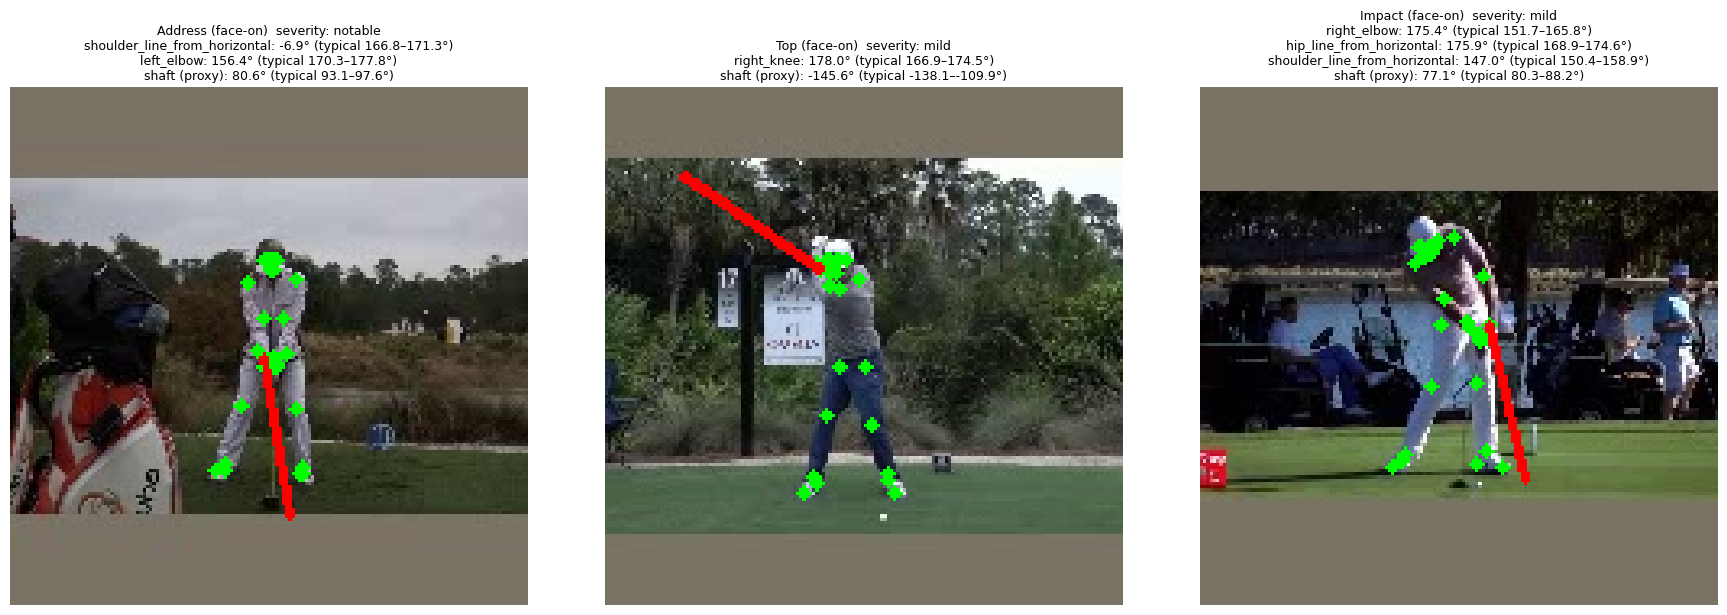

In [8]:
df_val = df_kp[
    df_kp['clip_id'].isin(splits['val'])
    & (df_kp['mean_visibility'] >= 0.3)
].copy()

rng_demo = np.random.default_rng(7)
demo_labels = ['Address', 'Top', 'Impact']
demo_rows = []
for label in demo_labels:
    cands = df_val[(df_val['label'] == label) & (df_val['view'] == 'face-on')]
    if len(cands) > 0:
        demo_rows.append(cands.iloc[rng_demo.integers(len(cands))])

fig, axes = plt.subplots(1, len(demo_rows), figsize=(6 * len(demo_rows), 6))
if len(demo_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, demo_rows):
    image_path = FRAMES_DIR / row['frame_filename']
    detection = detect_pose_and_shaft(image_path)
    deviation = compute_deviation(detection, p_position=row['label'], view=row['view'])
    img = cv2.imread(str(image_path))
    overlay = img.copy()
    if detection.get('keypoints') is not None:
        kp = detection['keypoints']
        h, w = img.shape[:2]
        for i in range(NUM_LANDMARKS):
            if kp[i, 2] > 0.5:
                cv2.circle(overlay, (int(kp[i, 0] * w), int(kp[i, 1] * h)), 2, (0, 255, 0), -1)
        # Draw the lead arm + shaft proxy as a single line
        if detection.get('shaft') is not None:
            shoulder_pt = (int(kp[11, 0] * w), int(kp[11, 1] * h))
            wrist_pt = (int(kp[15, 0] * w), int(kp[15, 1] * h))
            # Extend the arm direction past the wrist as the proxy shaft
            shaft_angle_rad = np.radians(detection['shaft']['angle_deg'])
            ext_x = int(wrist_pt[0] + 50 * np.cos(shaft_angle_rad))
            ext_y = int(wrist_pt[1] + 50 * np.sin(shaft_angle_rad))
            cv2.line(overlay, wrist_pt, (ext_x, ext_y), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    out_of_range = [d for d in deviation['joint_deviations'] if d['severity'] != 'within_typical_range']
    out_of_range.sort(key=lambda d: abs(d['deviation']), reverse=True)
    lines = [f'{row["label"]} ({row["view"]})  severity: {deviation["overall_severity"]}']
    for d in out_of_range[:3]:
        lines.append(f'{d["joint"]}: {d["observed"]}° (typical {d["p25"]}–{d["p75"]}°)')
    if deviation.get('shaft_deviation'):
        sd = deviation['shaft_deviation']
        lines.append(f'shaft (proxy): {sd["observed"]}° (typical {sd["p25"]}–{sd["p75"]}°)')
    ax.set_title('\n'.join(lines), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Phase 4b: Coaching corpus → embeddings → ChromaDB → retrieval

Takes the 16 coaching documents from `data/coaching_corpus/` and builds a retrieval system the agent can call.

**Pipeline:**
1. Read 16 markdown files, split each by section headings into structured chunks
2. Attach metadata (P-position, document type, fault name) to each chunk
3. Embed all chunks using `text-embedding-3-large`
4. Build a ChromaDB collection with the embeddings + metadata
5. Define `retrieve_advice(p_position, deviation_summary, top_k=3)`
6. Smoke-test retrieval on representative deviation queries

**Outputs:**
- `data/chroma_db/` — persistent ChromaDB store
- A `retrieve_advice(...)` function the agent will call in Phase 4c

## 1. Setup

In [9]:
import os
import re
import time
from pathlib import Path
from typing import Optional

from dotenv import load_dotenv
from openai import OpenAI
import chromadb

load_dotenv('../.env')
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

CORPUS_DIR = Path('../data/coaching_corpus')
CHROMA_DIR = Path('../data/chroma_db')
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL = 'text-embedding-3-large'
EMBEDDING_DIM = 3072  # text-embedding-3-large dimension

EVENT_NAMES = ['Address', 'Toe-up', 'Mid-backswing', 'Top',
               'Mid-downswing', 'Impact', 'Mid-followthrough', 'Finish']

# File-prefix → P-position label mapping (matches our 16 documents)
PREFIX_TO_LABEL = {
    'p1_address': 'Address',
    'p2_toeup': 'Toe-up',
    'p3_midbackswing': 'Mid-backswing',
    'p4_top': 'Top',
    'p5_middownswing': 'Mid-downswing',
    'p6_impact': 'Impact',
    'p7_midfollowthrough': 'Mid-followthrough',
    'p8_finish': 'Finish',
}

# Verify corpus exists
md_files = sorted(CORPUS_DIR.glob('*.md'))
md_files = [f for f in md_files if f.name != 'README.md']
print(f'Found {len(md_files)} markdown files in {CORPUS_DIR}')
if len(md_files) != 16:
    print(f'WARNING: expected 16 documents, found {len(md_files)}')
for f in md_files:
    print(f'  {f.name}')

Found 16 markdown files in ..\data\coaching_corpus
  p1_address_faults.md
  p1_address_form.md
  p2_toeup_faults.md
  p2_toeup_form.md
  p3_midbackswing_faults.md
  p3_midbackswing_form.md
  p4_top_faults.md
  p4_top_form.md
  p5_middownswing_faults.md
  p5_middownswing_form.md
  p6_impact_faults.md
  p6_impact_form.md
  p7_midfollowthrough_faults.md
  p7_midfollowthrough_form.md
  p8_finish_faults.md
  p8_finish_form.md


## 2. Chunking: split each markdown by section headings

Each `## Heading` in a fault document becomes a self-contained chunk. Each `## Heading` in a form document also becomes a chunk. The chunk text includes the heading itself (so embeddings have semantic context about what section this is).

In [10]:
def parse_markdown_to_chunks(filepath: Path) -> list[dict]:
    """Split a markdown file by `## ` section headings into a list of chunks.
    
    Each chunk: {'text', 'section_heading', 'document_filename', 'p_position',
                 'document_type', 'fault_name' (faults only)}
    """
    text = filepath.read_text(encoding='utf-8')
    
    # Determine document metadata from filename
    stem = filepath.stem  # e.g., 'p3_midbackswing_faults'
    if stem.endswith('_form'):
        doc_type = 'form'
        prefix = stem[:-len('_form')]
    elif stem.endswith('_faults'):
        doc_type = 'faults'
        prefix = stem[:-len('_faults')]
    else:
        raise ValueError(f'Unexpected filename pattern: {filepath.name}')
    
    if prefix not in PREFIX_TO_LABEL:
        raise ValueError(f'Unknown P-position prefix: {prefix}')
    p_position = PREFIX_TO_LABEL[prefix]
    
    # Split by `## ` headings (level-2). Keep content under each heading with the heading itself.
    # The first `# ` (level-1) heading is the document title — treat content before any ## as a single chunk too.
    sections = re.split(r'\n## ', text)
    # sections[0] is the title + any preamble before the first ##
    # sections[1:] each starts with the heading text (without the leading ##)
    
    chunks = []
    for i, section in enumerate(sections):
        section = section.strip()
        if not section:
            continue
        
        if i == 0:
            # Title section — use the document title as heading
            title_match = re.match(r'^# (.+?)\n', section)
            heading = title_match.group(1) if title_match else 'Document title'
            section_text = section
        else:
            # Sections 1+ have heading on first line
            first_newline = section.find('\n')
            if first_newline == -1:
                heading = section
                section_text = f'## {section}'
            else:
                heading = section[:first_newline].strip()
                section_text = f'## {section}'
        
        # Skip empty sections or notes-only sections
        if len(section_text) < 50:
            continue
        
        chunk = {
            'text': section_text,
            'section_heading': heading,
            'document_filename': filepath.name,
            'p_position': p_position,
            'document_type': doc_type,
        }
        
        # For faults documents, sections after the title are individual faults
        if doc_type == 'faults' and i > 0:
            # Convert heading to a fault_name slug
            fault_slug = re.sub(r'\([^)]*\)', '', heading)  # remove parenthetical text
            fault_slug = re.sub(r'[^a-zA-Z0-9 ]', '', fault_slug).strip().lower()
            fault_slug = re.sub(r'\s+', '_', fault_slug)
            chunk['fault_name'] = fault_slug
        else:
            chunk['fault_name'] = ''
        
        chunks.append(chunk)
    
    return chunks


# Build chunks from all 16 documents
all_chunks = []
for filepath in md_files:
    chunks = parse_markdown_to_chunks(filepath)
    all_chunks.extend(chunks)
    print(f'  {filepath.name}: {len(chunks)} chunks')

print(f'\nTotal chunks: {len(all_chunks)}')

# Distribution check
from collections import Counter
by_pos = Counter(c['p_position'] for c in all_chunks)
by_type = Counter(c['document_type'] for c in all_chunks)
print(f'\nBy P-position: {dict(by_pos)}')
print(f'By document type: {dict(by_type)}')

  p1_address_faults.md: 5 chunks
  p1_address_form.md: 5 chunks
  p2_toeup_faults.md: 5 chunks
  p2_toeup_form.md: 5 chunks
  p3_midbackswing_faults.md: 5 chunks
  p3_midbackswing_form.md: 5 chunks
  p4_top_faults.md: 5 chunks
  p4_top_form.md: 5 chunks
  p5_middownswing_faults.md: 5 chunks
  p5_middownswing_form.md: 5 chunks
  p6_impact_faults.md: 5 chunks
  p6_impact_form.md: 5 chunks
  p7_midfollowthrough_faults.md: 6 chunks
  p7_midfollowthrough_form.md: 5 chunks
  p8_finish_faults.md: 5 chunks
  p8_finish_form.md: 5 chunks

Total chunks: 81

By P-position: {'Address': 10, 'Toe-up': 10, 'Mid-backswing': 10, 'Top': 10, 'Mid-downswing': 10, 'Impact': 10, 'Mid-followthrough': 11, 'Finish': 10}
By document type: {'faults': 41, 'form': 40}


In [11]:
# Eyeball a few chunks to confirm parsing worked
for chunk in all_chunks[:3]:
    print(f'--- {chunk["document_filename"]} | section: {chunk["section_heading"]} | type: {chunk["document_type"]} ---')
    print(f'  fault_name: {chunk["fault_name"]}')
    print(f'  text (first 200 chars): {chunk["text"][:200]}...')
    print()

# Show a fault-document chunk specifically
fault_chunks = [c for c in all_chunks if c['document_type'] == 'faults' and c['fault_name']]
if fault_chunks:
    sample = fault_chunks[0]
    print(f'--- Sample fault chunk ---')
    print(f'  P-position: {sample["p_position"]}')
    print(f'  Fault name: {sample["fault_name"]}')
    print(f'  Section heading: {sample["section_heading"]}')
    print(f'  Text:')
    print(sample['text'])

--- p1_address_faults.md | section: Excessive forward bend (over the ball) | type: faults ---
  fault_name: excessive_forward_bend
  text (first 200 chars): ## Excessive forward bend (over the ball)

**What it looks like:** Spine angle from vertical greater than ~50°. The golfer is hunched over the ball, head low, shoulders rounded.

**Detection signal:**...

--- p1_address_faults.md | section: Insufficient knee flex (locked-out legs) | type: faults ---
  fault_name: insufficient_knee_flex
  text (first 200 chars): ## Insufficient knee flex (locked-out legs)

**What it looks like:** Knees nearly straight at address, often paired with a very upright torso. The golfer has no athletic readiness in the legs.

**Dete...

--- p1_address_faults.md | section: Open or closed shoulder line | type: faults ---
  fault_name: open_or_closed_shoulder_line
  text (first 200 chars): ## Open or closed shoulder line

**What it looks like:** The shoulder line is not parallel to the target line at address.

## 3. Embed all chunks with `text-embedding-3-large`

OpenAI's batch embedding API accepts up to 2048 inputs per call. Our ~80-120 chunks fit comfortably in one or two calls.

In [12]:
def embed_texts_batch(texts: list[str], model: str = EMBEDDING_MODEL) -> list[list[float]]:
    """Embed a list of texts. OpenAI batch endpoint accepts up to 2048 at once."""
    if not texts:
        return []
    response = client.embeddings.create(
        model=model,
        input=texts,
    )
    return [d.embedding for d in response.data]


print(f'Embedding {len(all_chunks)} chunks with {EMBEDDING_MODEL}...')
t0 = time.time()
texts = [c['text'] for c in all_chunks]
embeddings = embed_texts_batch(texts)
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s. Got {len(embeddings)} embeddings of dim {len(embeddings[0])}.')

# Sanity: dim matches expected
assert len(embeddings[0]) == EMBEDDING_DIM, f'Expected {EMBEDDING_DIM}-dim, got {len(embeddings[0])}'

Embedding 81 chunks with text-embedding-3-large...
Done in 4.0s. Got 81 embeddings of dim 3072.


## 4. Build the ChromaDB collection

Persistent client so the store survives kernel restarts. The agent in Phase 4c will load this same store rather than re-embedding.

Note: ChromaDB only supports primitive metadata types (str, int, float, bool). Lists and dicts must be flattened or excluded.

In [13]:
# Persistent client
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Drop existing collection if it exists (safe re-run)
COLLECTION_NAME = 'golf_coaching'
try:
    chroma_client.delete_collection(COLLECTION_NAME)
    print(f'Dropped existing collection "{COLLECTION_NAME}"')
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    metadata={'description': 'Golf coaching corpus chunks for swing-position deviation advice',
              'embedding_model': EMBEDDING_MODEL},
)

# Add all chunks
ids = [f'chunk_{i:04d}' for i in range(len(all_chunks))]
metadatas = [
    {
        'p_position': c['p_position'],
        'document_type': c['document_type'],
        'fault_name': c['fault_name'] or '',
        'section_heading': c['section_heading'],
        'document_filename': c['document_filename'],
    }
    for c in all_chunks
]

collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=texts,
    metadatas=metadatas,
)

print(f'Added {collection.count()} chunks to collection "{COLLECTION_NAME}"')
print(f'Persistent store at: {CHROMA_DIR.resolve()}')

Dropped existing collection "golf_coaching"
Added 81 chunks to collection "golf_coaching"
Persistent store at: C:\@code\GolfAIML\data\chroma_db


## 5. The `retrieve_advice` function

Given a P-position and a deviation summary, retrieve the most relevant coaching content.

Two-stage retrieval:
1. **Pre-filter** by P-position (and optionally `document_type='faults'` if we want only fault content).
2. **Semantic search** within the filtered subset using the embedded query.

The query string is constructed from the deviation summary in a way that surfaces the joint names and language the corpus uses.

In [14]:
def deviation_to_query(p_position: str, deviation_summary: dict) -> str:
    """Turn a structured deviation summary into a natural-language query for retrieval.
    
    Input format (matches what compute_deviation returns from Phase 4a):
      {'p_position': str, 'view': str, 'overall_severity': str,
       'joint_deviations': [{'joint', 'observed', 'p25', 'p75', 'median', 'deviation', 'severity'}, ...],
       'shaft_deviation': {...} or None}
    
    Strategy: enumerate the most-deviated joints in plain language, mentioning the
    direction (above/below typical) and using the joint names from our deviation system.
    """
    parts = [f'Coaching advice for {p_position} swing position.']
    
    # Sort deviations by severity, then by absolute deviation
    notable_first = sorted(
        deviation_summary.get('joint_deviations', []),
        key=lambda d: (
            {'notable': 0, 'mild': 1, 'within_typical_range': 2}[d.get('severity', 'within_typical_range')],
            -abs(d.get('deviation', 0)),
        ),
    )
    
    flagged = [d for d in notable_first if d.get('severity') != 'within_typical_range']
    
    if flagged:
        parts.append('Notable deviations:')
        for d in flagged[:3]:  # top 3 deviations only
            joint = d['joint']
            obs = d['observed']
            p25, p75 = d['p25'], d['p75']
            direction = 'below' if obs < p25 else 'above'
            parts.append(f'  {joint} is {obs}° ({direction} typical range {p25}-{p75}°)')
    
    shaft = deviation_summary.get('shaft_deviation')
    if shaft and shaft.get('severity') != 'within_typical_range':
        obs = shaft['observed']
        p25, p75 = shaft['p25'], shaft['p75']
        direction = 'below' if obs < p25 else 'above'
        parts.append(f'  shaft (lead-arm proxy) is {obs}° ({direction} typical range {p25}-{p75}°)')
    
    if not flagged and not shaft:
        parts.append('Form is generally within typical ranges; provide reinforcement and refinement notes.')
    
    return ' '.join(parts)


def retrieve_advice(
    p_position: str,
    deviation_summary: dict,
    top_k: int = 3,
    document_type: Optional[str] = None,
    collection=collection,
) -> list[dict]:
    """Retrieve coaching advice chunks relevant to a deviation summary.
    
    Args:
      p_position: 'Address', 'Top', etc. — pre-filters retrieval by position.
      deviation_summary: structured dict from compute_deviation().
      top_k: number of chunks to return.
      document_type: Optional filter for 'form' or 'faults' chunks only.
    
    Returns:
      List of dicts: {'text', 'metadata', 'distance', 'query_used'}
    """
    query = deviation_to_query(p_position, deviation_summary)
    query_emb = embed_texts_batch([query])[0]
    
    # Build the metadata filter
    where = {'p_position': p_position}
    if document_type:
        where = {'$and': [{'p_position': p_position}, {'document_type': document_type}]}
    
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        where=where,
    )
    
    out = []
    for i in range(len(results['ids'][0])):
        out.append({
            'text': results['documents'][0][i],
            'metadata': results['metadatas'][0][i],
            'distance': results['distances'][0][i],
            'query_used': query,
        })
    return out

# Phase 4c: The coaching agent

**The agent's job:** take a frame, return structured coaching feedback.

**Pipeline the agent orchestrates:**
1. Receive a frame image
2. Classify the P-position using the trained CNN
3. Run pose + shaft detection on the frame
4. Compute deviations from pro reference at the predicted P-position
5. Retrieve relevant coaching advice from the RAG store
6. Synthesize a structured coaching report

**Approach:** pydantic-ai agent with four tools. Structured pydantic output schema. GPT-5 mini as the orchestration model.

**Comparison demo:** at the end, we'll run the agent on 3-5 swings and compare its output to a baseline (just calling GPT-5 mini directly with the image and asking for coaching advice, no tools).

## 1. Load the trained CNN classifier

In [15]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Reuse settings from Phase 2's CNN section
CNN_WEIGHTS_PATH = Path('../data/results/cnn_mobilenetv2.pth')
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

EVENT_TO_IDX = {name: i for i, name in enumerate(EVENT_NAMES)}
IDX_TO_EVENT = {i: name for name, i in EVENT_TO_IDX.items()}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def build_classifier_model() -> nn.Module:
    """Same architecture as Phase 2 — MobileNetV2 with replaced head."""
    model = models.mobilenet_v2(weights=None)  # weights loaded from disk below
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, len(EVENT_NAMES)),
    )
    return model


if not CNN_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f'CNN weights not found at {CNN_WEIGHTS_PATH}. '
        'Re-run the CNN section in 02_classifiers.ipynb after adding the save-weights cell from Section 10 above.'
    )

_cnn_model = build_classifier_model().to(device)
_cnn_model.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location=device))
_cnn_model.eval()

_cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def classify_p_position(image_path: Path) -> dict:
    """Run the trained CNN on a single image, return the predicted P-position and confidence."""
    img = Image.open(image_path).convert('RGB')
    x = _cnn_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = _cnn_model(x)
        probs = torch.softmax(logits, dim=1)[0]
    pred_idx = int(probs.argmax().item())
    return {
        'p_position': IDX_TO_EVENT[pred_idx],
        'confidence': float(probs[pred_idx].item()),
        'all_probs': {IDX_TO_EVENT[i]: float(probs[i].item()) for i in range(len(EVENT_NAMES))},
    }


# Smoke test on a known frame from the validation set
sample_row = df_val.iloc[0]
sample_path = FRAMES_DIR / sample_row['frame_filename']
result = classify_p_position(sample_path)
print(f'Smoke test on {sample_row["frame_filename"]}:')
print(f'  True label:    {sample_row["label"]}')
print(f'  Predicted:     {result["p_position"]} (conf {result["confidence"]:.3f})')

Smoke test on clip1062_event1.jpg:
  True label:    Address
  Predicted:     Address (conf 1.000)


## 2. Define the agent's tools and structured output

Four tools the agent can call:
1. `tool_classify_p_position` — wraps the CNN
2. `tool_compute_deviation` — wraps `compute_deviation` (defined earlier)
3. `tool_retrieve_coaching_advice` — wraps `retrieve_advice` (defined earlier)

The agent's output is a Pydantic model so we get structured, validated coaching feedback every time.

In [16]:
from pydantic import BaseModel, Field
from typing import Literal, Optional

from pydantic_ai import Agent, RunContext
from pydantic_ai.models.openai import OpenAIModel

class DeviationFeedback(BaseModel):
    """One specific deviation the user should know about."""
    metric: str = Field(description='Which body or shaft metric (e.g., spine_angle_from_vertical)')
    observed_value: float = Field(description='The measured value in degrees')
    typical_range: str = Field(description='The typical pro range, formatted like "30-45°"')
    severity: Literal['mild', 'notable']
    explanation: str = Field(description='Plain-language explanation of what this deviation means')


class CoachingReport(BaseModel):
    """The structured output the agent produces for every analyzed frame."""
    p_position: str = Field(description='The detected swing position')
    classifier_confidence: float = Field(description='How confident the classifier was in the P-position prediction')
    overall_assessment: Literal['good', 'mild_issues', 'notable_issues']
    summary: str = Field(description='2-3 sentence high-level summary of what the swing looks like at this position')
    key_deviations: list[DeviationFeedback] = Field(description='The most important deviations to highlight, max 3')
    coaching_recommendations: list[str] = Field(
        description='2-4 specific, actionable recommendations grounded in the retrieved coaching corpus'
    )
    sources_used: list[str] = Field(
        description='Filenames of corpus documents that informed the recommendations',
        default_factory=list,
    )

class JointDeviation(BaseModel):
    joint: str
    observed: float
    p25: float
    p75: float
    median: float
    deviation: float
    severity: Literal['within_typical_range', 'mild', 'notable']


class ShaftDeviation(BaseModel):
    observed: float
    p25: float
    p75: float
    median: float
    deviation: float
    severity: Literal['within_typical_range', 'mild', 'notable']
    method: str
    proxy_confidence: float
    note: str


class DeviationSummary(BaseModel):
    p_position: str
    view: str
    joint_deviations: list[JointDeviation]
    shaft_deviation: Optional[ShaftDeviation] = None
    overall_severity: Literal['good', 'mild', 'notable']


class CoachingDeps(BaseModel):
    """Dependencies bundled into the agent's run context."""
    image_path: str  # path to the frame being analyzed
    view: Literal['face-on', 'down-the-line']  # known a priori in our pipeline

    model_config = {'arbitrary_types_allowed': True}


print('Schema and deps defined.')

Schema and deps defined.


In [17]:
AGENT_SYSTEM_PROMPT = '''You are an expert golf coach analyzing a single frame of a golf swing.

Your task: produce a structured coaching report grounded in:
  1. The position classifier's prediction
  2. The deviations from typical pro ranges at the predicted position
  3. The coaching corpus chunks retrieved for the most relevant faults

Process for every frame:
  Step 1: Call `tool_classify_p_position` to get the P-position prediction.
  Step 2: Call `tool_compute_deviation` with the P-position to compute deviations from pro form.
  Step 3: Call `tool_retrieve_coaching_advice` with the P-position to fetch relevant corpus content.
  Step 4: Synthesize the structured CoachingReport.

Important rules about interpreting deviations:
  - Tour pros vary substantially in their swings. Many fall outside even the p25-p75 range on individual joints — this is natural style variation, not a fault.
  - Only call out deviations that are tagged "notable" by the deviation tool. "Mild" deviations may be mentioned briefly as observations but should NOT be presented as faults.
  - If overall_severity is "good", the swing is technically sound. Do not invent issues. The report should reinforce what is being done well rather than fabricate problems.
  - Each joint metric is only reliable from one camera view. The deviation tool already filters out non-diagnostic metrics, so trust the inputs.
  - If a deviation has no obvious named fault counterpart in the retrieved coaching corpus, do not invent a name (e.g., do not call something "early extension" if the retrieved corpus chunks do not describe it as such for this position).

Important rules about output:
  - Ground every coaching recommendation in the retrieved corpus content. Do not invent advice.
  - When the classifier confidence is below 0.7, mention this uncertainty in the summary.
  - When the shaft proxy_confidence is below 0.4, omit shaft-related feedback. The proxy is geometrically unreliable at high-wrist-hinge positions (Top, Finish).
  - When the shaft proxy_confidence is between 0.4 and 0.7, hedge shaft-related feedback ("estimated from arm position").
  - Keep the summary concise (2-3 sentences). For technically sound swings, keep summaries short and complimentary.
  - Pick at most 2 deviations for key_deviations, and only include them if they are "notable" severity. For "good" or "mild" overall swings, key_deviations may be an empty list.
  - For "good" overall_assessment, coaching_recommendations should be 1-2 reinforcement notes ("continue to maintain..."), not faults to fix.
  - The sources_used field should list the document filenames returned by retrieve_coaching_advice.'''


agent_model = OpenAIModel('gpt-5-mini')

agent = Agent(
    model=agent_model,
    deps_type=CoachingDeps,
    output_type=CoachingReport,
    system_prompt=AGENT_SYSTEM_PROMPT,
)


@agent.tool
def tool_classify_p_position(ctx: RunContext[CoachingDeps]) -> dict:
    """Run the trained CNN classifier on the frame.
    Returns: {'p_position': str, 'confidence': float, 'all_probs': dict}"""
    return classify_p_position(Path(ctx.deps.image_path))


@agent.tool
def tool_compute_deviation(ctx: RunContext[CoachingDeps], p_position: str) -> dict:
    detection = detect_pose_and_shaft(Path(ctx.deps.image_path), p_position=p_position)
    return compute_deviation(detection, p_position=p_position, view=ctx.deps.view)


@agent.tool
def tool_retrieve_coaching_advice(
    ctx: RunContext[CoachingDeps],
    p_position: str,
    top_k: int = 3,
) -> list[dict]:
    """Retrieve relevant coaching corpus chunks for the given P-position.
    Re-uses the deterministic deviation pipeline internally so retrieval
    grounds on real measurements, not LLM-paraphrased structures.
    """
    detection = detect_pose_and_shaft(Path(ctx.deps.image_path), p_position=p_position)
    deviation_summary = compute_deviation(
        detection, p_position=p_position, view=ctx.deps.view
    )
    results = retrieve_advice(
        p_position, deviation_summary, top_k=top_k, document_type='faults'
    )
    return [
        {
            'text': r['text'],
            'document': r['metadata']['document_filename'],
            'section': r['metadata']['section_heading'],
            'distance': round(r['distance'], 3),
        }
        for r in results
    ]


print('Agent and tools defined. Ready to run.')

Agent and tools defined. Ready to run.

C:\Users\Jacob\AppData\Local\Temp\ipykernel_4836\1066437318.py:32: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  agent_model = OpenAIModel('gpt-5-mini')


## 3. Run the agent on a single frame

In [18]:
import asyncio

sample_row = df_val.iloc[5]
sample_path = FRAMES_DIR / sample_row['frame_filename']
print(f'Analyzing frame: {sample_row["frame_filename"]}')
print(f'  Ground truth: {sample_row["label"]} ({sample_row["view"]})')

deps = CoachingDeps(
    image_path=str(sample_path),
    view=sample_row['view'],
)

user_message = (
    'Analyze this golf swing frame and provide a structured coaching report. '
    'Use all four tools in sequence as instructed.'
)

result = await agent.run(user_message, deps=deps)
report = result.output

print('\n=== COACHING REPORT ===')
print(f'Position: {report.p_position} (classifier confidence {report.classifier_confidence:.3f})')
print(f'Overall: {report.overall_assessment}')
print(f'\nSummary: {report.summary}')
print(f'\nKey deviations:')
for d in report.key_deviations:
    print(f'  - {d.metric}: {d.observed_value}° (typical {d.typical_range}) — {d.severity}')
    print(f'    {d.explanation}')
print(f'\nRecommendations:')
for i, rec in enumerate(report.coaching_recommendations, 1):
    print(f'  {i}. {rec}')
print(f'\nSources used: {report.sources_used}')

Analyzing frame: clip1062_event6.jpg
  Ground truth: Impact (down-the-line)


C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



=== COACHING REPORT ===
Position: Impact (classifier confidence 0.994)
Overall: good

Summary: This frame is Impact and the classifier is highly confident. Measured joint angles (spine, hips, shoulders) fall within typical pro ranges, indicating a technically sound impact position — keep reinforcing these fundamentals.

Key deviations:

Recommendations:
  1. Continue to maintain your spine angle and rotate the hips through impact — cue: “belt buckle turns to face the target, not the ball.” Drill: practice downswing rotations with a wall behind the trail hip so any forward thrust is immediately felt (from p6_impact_faults.md).
  2. Keep the lead wrist neutral or slightly bowed at impact to ensure a square clubface — use slow-motion mirror checks and/or hold an alignment rod against the lead wrist to confirm the position (from p6_impact_faults.md).

Sources used: ['p6_impact_faults.md']


## 4. Demo on 3-5 swings — and compare to a no-tools baseline

The agent's value comes from grounding its feedback in measured deviations and retrieved coaching content. To make this visible, we compare:

- **Agent**: full pipeline (classifier → pose → deviation → RAG → structured report)
- **Baseline**: same model (GPT-5 mini) given the image directly with the same task description, no tools

Both produce coaching feedback. We expect the agent's feedback to:
  - Cite specific measurable values ("spine angle 18°")
  - Ground recommendations in named faults from the corpus
  - Show consistency across runs (deterministic up to LLM temperature)

And the baseline to:
  - Produce more generic advice
  - Not cite specific numerical deviations
  - Vary more across runs

In [19]:
rng_demo = np.random.default_rng(42)
demo_specs = [
    ('Address', 'face-on'),
    ('Top', 'face-on'),
    ('Mid-downswing', 'face-on'),
    ('Impact', 'down-the-line'),
]
demo_rows = []
for label, view in demo_specs:
    cands = df_val[(df_val['label'] == label) & (df_val['view'] == view)]
    if len(cands) > 0:
        demo_rows.append(cands.iloc[rng_demo.integers(len(cands))])
    else:
        print(f'No validation frame for {label} / {view} — skipping')

print(f'Selected {len(demo_rows)} demo frames.')
for r in demo_rows:
    print(f'  {r["frame_filename"]}: {r["label"]} / {r["view"]}')

Selected 4 demo frames.
  clip0546_event1.jpg: Address / face-on
  clip1353_event4.jpg: Top / face-on
  clip0704_event5.jpg: Mid-downswing / face-on
  clip0688_event6.jpg: Impact / down-the-line


In [20]:
agent_reports = []

for row in demo_rows:
    print(f'\nRunning agent on {row["frame_filename"]} (true label: {row["label"]})...')
    deps = CoachingDeps(
        image_path=str(FRAMES_DIR / row['frame_filename']),
        view=row['view'],
    )
    result = await agent.run(
        'Analyze this golf swing frame and provide a structured coaching report. '
        'Use all four tools in sequence as instructed.',
        deps=deps,
    )
    agent_reports.append({
        'frame': row['frame_filename'],
        'true_label': row['label'],
        'view': row['view'],
        'report': result.output,
        'usage': result.usage(),
    })
    print(f'  Predicted: {result.output.p_position} (conf {result.output.classifier_confidence:.3f})')
    print(f'  Overall: {result.output.overall_assessment}')

print(f'\nDone. Agent runs complete on {len(agent_reports)} frames.')


Running agent on clip0546_event1.jpg (true label: Address)...
  Predicted: Address (conf 0.993)
  Overall: mild_issues

Running agent on clip1353_event4.jpg (true label: Top)...
  Predicted: Top (conf 0.996)
  Overall: good

Running agent on clip0704_event5.jpg (true label: Mid-downswing)...
  Predicted: Mid-downswing (conf 0.998)
  Overall: mild_issues

Running agent on clip0688_event6.jpg (true label: Impact)...
  Predicted: Address (conf 0.950)
  Overall: notable_issues

Done. Agent runs complete on 4 frames.


In [21]:
import base64

BASELINE_PROMPT = '''You are an expert golf coach analyzing a single frame of a golf swing.
Identify which position in the swing this is (Address, Toe-up, Mid-backswing, Top, Mid-downswing,
Impact, Mid-followthrough, or Finish), then give the golfer specific coaching feedback:
what they're doing well, what's off, and 2-3 specific things to work on.
Keep your response under 250 words.'''


def encode_image_b64(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')


baseline_reports = []

for row in demo_rows:
    image_path = FRAMES_DIR / row['frame_filename']
    print(f'\nRunning baseline on {row["frame_filename"]}...')
    b64 = encode_image_b64(image_path)
    response = client.chat.completions.create(
        model='gpt-5-mini',
        messages=[
            {'role': 'system', 'content': BASELINE_PROMPT},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'Analyze this swing frame and give coaching feedback.'},
                {'type': 'image_url',
                 'image_url': {
                     'url': f'data:image/jpeg;base64,{b64}',
                     'detail': 'high',
                 }},
            ]},
        ],
        max_completion_tokens=2000,
        reasoning_effort='medium',
    )
    baseline_reports.append({
        'frame': row['frame_filename'],
        'true_label': row['label'],
        'view': row['view'],
        'response': response.choices[0].message.content,
    })

print(f'\nDone. Baseline runs complete on {len(baseline_reports)} frames.')


Running baseline on clip0546_event1.jpg...

Running baseline on clip1353_event4.jpg...

Running baseline on clip0704_event5.jpg...

Running baseline on clip0688_event6.jpg...

Done. Baseline runs complete on 4 frames.


In [22]:
# Side-by-side comparison
for i, (a, b) in enumerate(zip(agent_reports, baseline_reports)):
    print('=' * 80)
    print(f'Frame {i+1}: {a["frame"]}')
    print(f'True label: {a["true_label"]} ({a["view"]})')
    print('=' * 80)

    print(f'\n--- AGENT (with tools) ---')
    print(f'Predicted: {a["report"].p_position} (conf {a["report"].classifier_confidence:.3f})')
    print(f'Assessment: {a["report"].overall_assessment}')
    print(f'Summary: {a["report"].summary}')
    print(f'Key deviations:')
    for d in a['report'].key_deviations:
        print(f'  - {d.metric}: {d.observed_value}° (typical {d.typical_range}) [{d.severity}]')
        print(f'    {d.explanation}')
    print(f'Recommendations:')
    for j, rec in enumerate(a['report'].coaching_recommendations, 1):
        print(f'  {j}. {rec}')
    print(f'Sources: {a["report"].sources_used}')

    print(f'\n--- BASELINE (no tools) ---')
    print(b['response'])
    print()

Frame 1: clip0546_event1.jpg
True label: Address (face-on)

--- AGENT (with tools) ---
Predicted: Address (conf 0.993)
Assessment: mild_issues
Summary: This frame is a clear Address setup with posture and limb angles largely within typical pro ranges. There are only mild deviations (a slightly greater spine tilt from vertical and a small right-knee difference versus the pro median); the shaft direction was estimated from the lead-arm pose. Overall the setup is serviceable but worth a quick check with the drills below.
Key deviations:
Recommendations:
  1. Check/maintain an athletic amount of knee flex: adopt the posture so you 'could jump' from it. Drill from p1_address_faults.md — assume your address with eyes closed, then open and confirm knees are bent enough that a gentle downward push wouldn’t tip you forward.
  2. Confirm spine/head height and distance to the ball by letting the club set the spacing: place a club on the ground perpendicular to the target line and address so your 

### Save demo

In [23]:
import json

demo_dir = Path('../data/results/agent_demo')
demo_dir.mkdir(parents=True, exist_ok=True)

# Agent reports as JSON (Pydantic serializes cleanly)
agent_serializable = [
    {
        'frame': a['frame'],
        'true_label': a['true_label'],
        'view': a['view'],
        'report': a['report'].model_dump(),
    }
    for a in agent_reports
]
with open(demo_dir / 'agent_reports.json', 'w') as f:
    json.dump(agent_serializable, f, indent=2)

with open(demo_dir / 'baseline_reports.json', 'w') as f:
    json.dump(baseline_reports, f, indent=2)

print(f'Saved demo artifacts to {demo_dir}')
print(f'  agent_reports.json: {len(agent_serializable)} frames')
print(f'  baseline_reports.json: {len(baseline_reports)} frames')

Saved demo artifacts to ..\data\results\agent_demo
  agent_reports.json: 4 frames
  baseline_reports.json: 4 frames


# Phase 4d trace: pipeline walkthrough for one clip

Produces a concrete, end-to-end trace of the coaching agent pipeline for a single clip. Output is intended for the report's Coaching Agent chapter

1. **Step 1 — Input**: the frame image with metadata
2. **Step 2 — Classifier output**: predicted P-position, confidence, top-3 alternatives
3. **Step 3 — Pose detection**: keypoints overlaid on the image, joint angles printed
4. **Step 4 — Deviation analysis**: side-by-side comparison of observed vs pro reference
5. **Step 5 — Retrieved coaching chunks**: the corpus content the RAG pipeline pulled
6. **Step 6 — Final coaching report**: the structured CoachingReport synthesized by the agent

### Picking a random clip (frame)

In [24]:
from pathlib import Path
import json

TRACE_CLIP = 'clip1353_event4.jpg'

TRACE_DIR = Path('../data/results/agent_demo') / f'trace_{TRACE_CLIP.replace(".jpg", "")}'
TRACE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Trace will be written to: {TRACE_DIR.resolve()}')

# Find the corresponding report from the agent demo
with open('../data/results/agent_demo/agent_reports.json') as f:
    saved_reports = json.load(f)
trace_report = next(r for r in saved_reports if r['frame'] == TRACE_CLIP)
trace_clip_id = int(TRACE_CLIP.replace('clip', '').split('_')[0])
trace_event_idx = int(TRACE_CLIP.replace('.jpg', '').split('event')[-1])
print(f'Tracing clip {trace_clip_id} at event {trace_event_idx} (true label: {trace_report["true_label"]})')

Trace will be written to: C:\@code\GolfAIML\data\results\agent_demo\trace_clip1353_event4
Tracing clip 1353 at event 4 (true label: Top)


## 1. Input

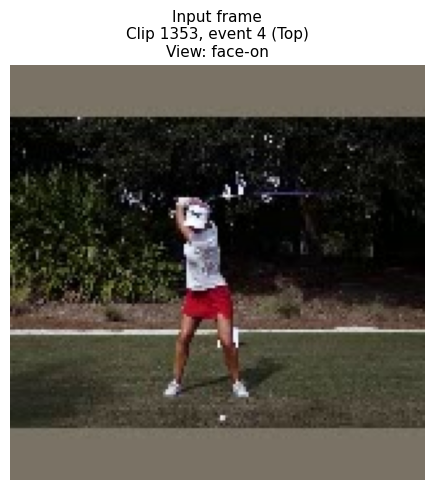

Saved → ..\data\results\agent_demo\trace_clip1353_event4\step1_input.png


In [25]:
import cv2
import matplotlib.pyplot as plt

image_path = FRAMES_DIR / TRACE_CLIP
img = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img_rgb)
ax.set_title(
    f'Input frame\n'
    f'Clip {trace_clip_id}, event {trace_event_idx} ({trace_report["true_label"]})\n'
    f'View: {trace_report["view"]}',
    fontsize=11,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(TRACE_DIR / 'step1_input.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {TRACE_DIR / "step1_input.png"}')

## 2. Classifier output

The trained CNN (MobileNetV2) returns a probability distribution over the 8 P-positions.

Predicted: Top (confidence 0.996)

Top-3 alternatives:
  Top                  0.996  ███████████████████████████████████████
  Mid-downswing        0.002  
  Toe-up               0.001  


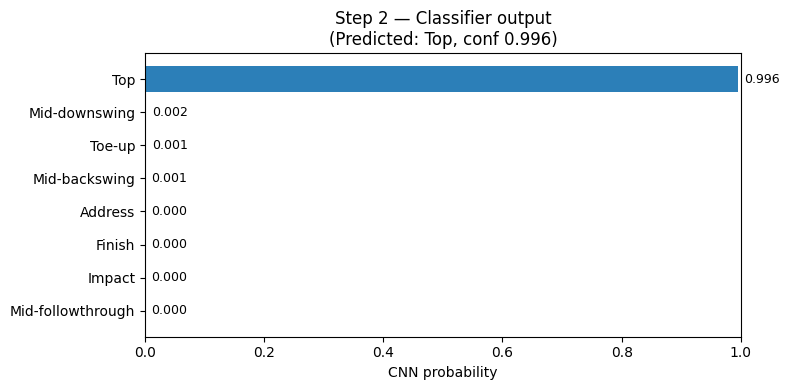

Saved → ..\data\results\agent_demo\trace_clip1353_event4\step2_classification.png


In [26]:
import numpy as np

classification = classify_p_position(image_path)
predicted_pos = classification['p_position']
predicted_conf = classification['confidence']
all_probs = classification['all_probs']

# Top-3 alternatives
sorted_probs = sorted(all_probs.items(), key=lambda x: x[1], reverse=True)
top3 = sorted_probs[:3]

print(f'Predicted: {predicted_pos} (confidence {predicted_conf:.3f})')
print(f'\nTop-3 alternatives:')
for label, prob in top3:
    bar = '█' * int(prob * 40)
    print(f'  {label:20s} {prob:.3f}  {bar}')

# Bar plot
fig, ax = plt.subplots(figsize=(8, 4))
labels = [s[0] for s in sorted_probs]
probs = [s[1] for s in sorted_probs]
colors = ['#2c7fb8' if l == predicted_pos else '#bbbbbb' for l in labels]
ax.barh(range(len(labels)), probs, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('CNN probability')
ax.set_title(f'Step 2 — Classifier output\n(Predicted: {predicted_pos}, conf {predicted_conf:.3f})')
ax.set_xlim(0, 1)
for i, (label, prob) in enumerate(zip(labels, probs)):
    ax.text(prob + 0.01, i, f'{prob:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(TRACE_DIR / 'step2_classification.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {TRACE_DIR / "step2_classification.png"}')

## 3. Pose detection

MediaPipe extracts 33 keypoints + lead-arm shaft proxy. Joint angles are computed from these.

C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


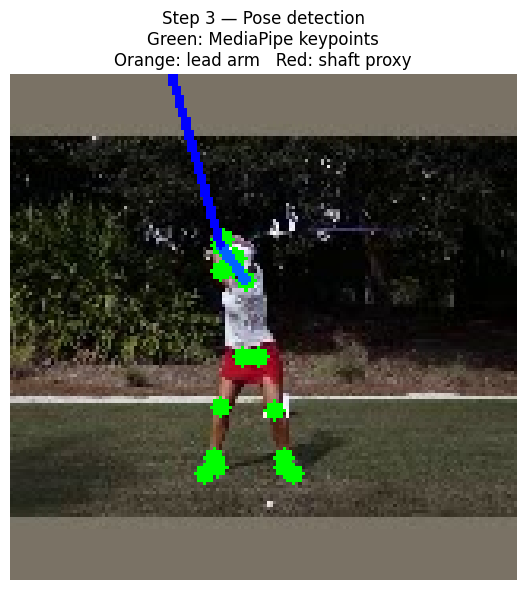


Joint angles computed:
  left_elbow                           108.03°
  right_elbow                          138.65°
  left_shoulder                        122.42°
  right_shoulder                       102.73°
  left_hip                             175.38°
  right_hip                            157.94°
  left_knee                            177.35°
  right_knee                           163.53°
  spine_angle_from_vertical             -4.48°
  hip_line_from_horizontal             176.75°
  shoulder_line_from_horizontal       -170.82°

Shaft proxy:
  angle: -105.44°  confidence: 0.70
Saved → ..\data\results\agent_demo\trace_clip1353_event4\step3_pose.png


In [27]:
detection = detect_pose_and_shaft(image_path)
kp = detection['keypoints']
joint_angles = detection['joint_angles']
shaft = detection['shaft']

# Visualize keypoints + lead-arm proxy on the image
fig, ax = plt.subplots(figsize=(6, 6))
overlay = img.copy()
h, w = img.shape[:2]
if kp is not None:
    for i in range(NUM_LANDMARKS):
        if kp[i, 2] > 0.5:
            x = int(kp[i, 0] * w)
            y = int(kp[i, 1] * h)
            cv2.circle(overlay, (x, y), 3, (0, 255, 0), -1)
    # Lead-arm proxy as a line from shoulder through wrist, extended
    if shaft is not None:
        sh_x, sh_y = int(kp[11, 0] * w), int(kp[11, 1] * h)
        wr_x, wr_y = int(kp[15, 0] * w), int(kp[15, 1] * h)
        cv2.line(overlay, (sh_x, sh_y), (wr_x, wr_y), (255, 100, 0), 2)
        # Extend
        ang = np.radians(shaft['angle_deg'])
        ext_x = int(wr_x + 60 * np.cos(ang))
        ext_y = int(wr_y + 60 * np.sin(ang))
        cv2.line(overlay, (wr_x, wr_y), (ext_x, ext_y), (255, 0, 0), 2)
ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
ax.set_title('Step 3 — Pose detection\nGreen: MediaPipe keypoints\nOrange: lead arm   Red: shaft proxy')
ax.axis('off')
plt.tight_layout()
plt.savefig(TRACE_DIR / 'step3_pose.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'\nJoint angles computed:')
for joint, angle in joint_angles.items():
    if angle is not None:
        print(f'  {joint:35s} {angle:7.2f}°')
if shaft is not None:
    print(f'\nShaft proxy:')
    print(f'  angle: {shaft["angle_deg"]:.2f}°  confidence: {shaft["confidence"]:.2f}')
print(f'Saved → {TRACE_DIR / "step3_pose.png"}')

## 4. Deviation analysis

Compare observed joint angles against the pro reference distribution at the predicted P-position and view.

Step 4 — Deviation summary (overall: good)

                       metric observed pro range (p25-p75) pro median deviation             severity
                   left_elbow   108.0°         93.8-126.2°     110.8°        0° within_typical_range
                  right_elbow   138.7°         90.3-155.6°     131.5°        0° within_typical_range
                    left_knee   177.4°        165.7-174.2°     171.4°        0° within_typical_range
                   right_knee   163.5°        166.9-174.5°     171.7°        0° within_typical_range
    spine_angle_from_vertical    -4.5°         -10.3--3.2°      -6.6°        0° within_typical_range
     hip_line_from_horizontal   176.7°       -176.8-177.8°     174.6°        0° within_typical_range
shoulder_line_from_horizontal  -170.8°       -167.7-174.8°     168.4°        0° within_typical_range
       shaft (lead-arm proxy)  -105.4°      -138.1--109.9°    -124.5°        0° within_typical_range

Saved → ..\data\results\agent_demo\trace_clip1

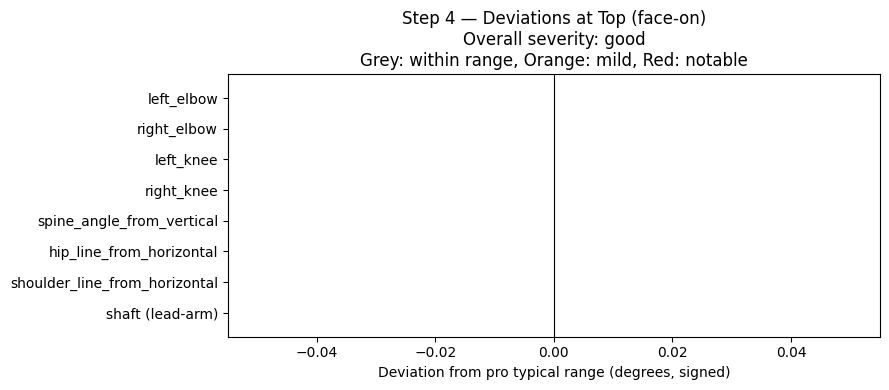

Saved → ..\data\results\agent_demo\trace_clip1353_event4\step4_deviations.png


In [28]:
deviation = compute_deviation(detection, p_position=predicted_pos, view=trace_report['view'])

import pandas as pd
rows_dev = []
for d in deviation['joint_deviations']:
    rows_dev.append({
        'metric': d['joint'],
        'observed': f'{d["observed"]:.1f}°',
        'pro range (p25-p75)': f'{d["p25"]:.1f}-{d["p75"]:.1f}°',
        'pro median': f'{d["median"]:.1f}°',
        'deviation': f'{d["deviation"]:+.1f}°' if d['deviation'] != 0 else '0°',
        'severity': d['severity'],
    })
if deviation.get('shaft_deviation'):
    s = deviation['shaft_deviation']
    rows_dev.append({
        'metric': 'shaft (lead-arm proxy)',
        'observed': f'{s["observed"]:.1f}°',
        'pro range (p25-p75)': f'{s["p25"]:.1f}-{s["p75"]:.1f}°',
        'pro median': f'{s["median"]:.1f}°',
        'deviation': f'{s["deviation"]:+.1f}°' if s['deviation'] != 0 else '0°',
        'severity': s['severity'],
    })
deviation_df = pd.DataFrame(rows_dev)
deviation_df.to_csv(TRACE_DIR / 'step4_deviations.csv', index=False)

print(f'Step 4 — Deviation summary (overall: {deviation["overall_severity"]})')
print()
print(deviation_df.to_string(index=False))
print()
print(f'Saved → {TRACE_DIR / "step4_deviations.csv"}')

color_map = {'within_typical_range': '#888888', 'mild': '#fdae61', 'notable': '#d7191c'}
all_devs = list(deviation['joint_deviations'])
if deviation.get('shaft_deviation'):
    all_devs.append({**deviation['shaft_deviation'], 'joint': 'shaft (lead-arm)'})

labels_d = [d.get('joint', d.get('metric', '?')) for d in all_devs]
deviations_val = [d['deviation'] for d in all_devs]
colors_d = [color_map.get(d['severity'], '#888888') for d in all_devs]

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(labels_d))))
ax.barh(range(len(labels_d)), deviations_val, color=colors_d)
ax.set_yticks(range(len(labels_d)))
ax.set_yticklabels(labels_d)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Deviation from pro typical range (degrees, signed)')
ax.set_title(f'Step 4 — Deviations at {predicted_pos} ({trace_report["view"]})\n'
             f'Overall severity: {deviation["overall_severity"]}\n'
             f'Grey: within range, Orange: mild, Red: notable')
plt.tight_layout()
plt.savefig(TRACE_DIR / 'step4_deviations.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {TRACE_DIR / "step4_deviations.png"}')

## 5. Retrieved coaching chunks

The RAG pipeline embeds the deviation summary as a query and retrieves the top-k most-similar coaching corpus chunks.

In [29]:
# Reproduce what the agent's retrieve tool does
retrieval_query = deviation_to_query(predicted_pos, deviation)
retrieval_results = retrieve_advice(
    predicted_pos, deviation, top_k=3, document_type='faults'
)

print(f'Retrieval query (the text that was embedded):\n')
print(retrieval_query)
print()
print(f'\nRetrieved chunks (top {len(retrieval_results)}):')
print()
for i, r in enumerate(retrieval_results, 1):
    print(f'--- Chunk {i} (distance: {r["distance"]:.4f}) ---')
    print(f'  Source: {r["metadata"]["document_filename"]} | section: {r["metadata"]["section_heading"]}')
    print()
    print(r['text'])
    print()

with open(TRACE_DIR / 'step5_retrieval.md', 'w') as f:
    f.write('# Step 5 — Retrieval trace\n\n')
    f.write(f'## Query embedded\n\n```\n{retrieval_query}\n```\n\n')
    f.write(f'## Retrieved chunks\n\n')
    for i, r in enumerate(retrieval_results, 1):
        f.write(f'### Chunk {i} (distance {r["distance"]:.4f})\n\n')
        f.write(f'**Source**: `{r["metadata"]["document_filename"]}` | section: *{r["metadata"]["section_heading"]}*\n\n')
        f.write(f'```\n{r["text"]}\n```\n\n')
print(f'Saved → {TRACE_DIR / "step5_retrieval.md"}')

Retrieval query (the text that was embedded):

Coaching advice for Top swing position.


Retrieved chunks (top 3):

--- Chunk 1 (distance: 0.9096) ---
  Source: p4_top_faults.md | section: Overswinging (club past parallel)

## Overswinging (club past parallel)

**What it looks like:** The club swings past the parallel-to-ground position at the top, sometimes reaching a nearly vertical shaft angle pointing toward the ground. The lead arm is typically well above horizontal, and the lead elbow often collapses significantly to allow the extra range.

**Detection signal:** `shaft proxy angle` indicating the club past parallel (shaft angle greater than 100° past vertical); `left_elbow` angle substantially below 150°; `left_shoulder` elevated significantly above horizontal.

**Why it happens:** Usually results from a collapsed lead arm, excessive wrist hinge, or very loose grip pressure allowing the club to slide in the fingers. Can also stem from trying to generate more power by swinging lon

## 6. Final coaching report

The agent's structured `CoachingReport` output, drawn from the saved `agent_reports.json`.

In [30]:
report = trace_report['report']  # already loaded from agent_reports.json

print(f'Step 6 — Final coaching report')
print('=' * 60)
print(f'P-position: {report["p_position"]}')
print(f'Classifier confidence: {report["classifier_confidence"]:.3f}')
print(f'Overall assessment: {report["overall_assessment"]}')
print()
print(f'Summary:')
print(f'  {report["summary"]}')
print()
print(f'Key deviations ({len(report["key_deviations"])} surfaced):')
for d in report['key_deviations']:
    print(f'  • {d["metric"]}: {d["observed_value"]:.1f}° ({d["severity"]})')
    print(f'    typical: {d["typical_range"]}')
    print(f'    {d["explanation"]}')
    print()
print(f'Coaching recommendations:')
for i, rec in enumerate(report['coaching_recommendations'], 1):
    print(f'  {i}. {rec}')
    print()
print(f'Sources used: {report["sources_used"]}')

with open(TRACE_DIR / 'step6_final_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f'\nSaved → {TRACE_DIR / "step6_final_report.json"}')

Step 6 — Final coaching report
P-position: Top
Classifier confidence: 0.996
Overall assessment: good

Summary:
  The frame is classified as Top (confidence 0.996). Measured joint angles (shoulders, spine, elbows, knees) all fall within typical pro ranges and the overall assessment is technically sound — no notable faults were detected. Shaft-direction estimates are unreliable for this frame so shaft comments are omitted.

Key deviations (0 surfaced):
Coaching recommendations:
  1. Reinforce a rotation-led backswing: continue to prioritize shoulder/torso rotation depth rather than trying to gain extra length with the arms — a useful practice is to make controlled backswings that stop when the lead arm reaches parallel (p4_top_faults.md).

  2. Maintain the connection of the trail arm/elbow through the top — keep feeling the trail elbow 'pocketed' toward the trail hip; a simple drill is to swing with a headcover or glove tucked under the trail armpit to preserve that connection (p4_top_f

# Phase 4e: Full-swing sequential analysis

Takes a complete clip (8 event frames, P1 through P8) and runs the agent sequentially across all 8 frames. Each frame's analysis includes a compact summary of the prior P-positions' findings, so by P8 the agent has a coherent view of the whole swing.

### Output

A `SwingReport` covering the entire swing:
- 8 per-position `CoachingReport`s (one per event)
- A top-level synthesis with prioritized issues, per-position summaries, and any propagation patterns observed across the swing

## 1. Full-swing schemas

Two schemas are defined: `FullSwingReport` (technical, intermediate/advanced audience) and `BeginnerSwingReport` (plain-English, entry-level audience). Both are produced by the pipeline.

In [31]:
from pydantic import BaseModel, Field
from typing import Literal


class PriorityIssue(BaseModel):
    """A high-priority issue spanning one or more swing positions."""
    issue_name: str = Field(description='Short name (e.g., "early extension", "casting")')
    affected_positions: list[str] = Field(
        description='P-positions where this issue showed up, e.g., ["Mid-backswing", "Mid-downswing"]'
    )
    severity: Literal['mild', 'notable']
    explanation: str = Field(description='What the issue is and how it propagates through the swing')
    primary_recommendation: str = Field(
        description='Single most actionable thing the golfer should work on for this issue'
    )


class FullSwingReport(BaseModel):
    """Top-level synthesis across all 8 P-positions."""
    clip_id: int
    overall_assessment: Literal['good', 'mild_issues', 'notable_issues']
    headline_summary: str = Field(
        description='3-4 sentences: the most important things to know about this swing'
    )
    priority_issues: list[PriorityIssue] = Field(
        description='2-4 most important issues to work on, ordered by importance',
    )
    per_position_summary: dict[str, str] = Field(
        description='One sentence per P-position summarizing what was observed at that position'
    )
    propagation_observations: list[str] = Field(
        description='Patterns where one P-position\'s issue caused or amplified an issue at a later P-position',
        default_factory=list,
    )
    classifier_disagreements: list[str] = Field(
        description='P-positions where the CNN classification disagreed with the temporal label',
        default_factory=list,
    )



class BeginnerTakeaway(BaseModel):
    """One plain-English coaching point for an entry-level golfer."""
    title: str = Field(description='3-6 words, no technical jargon')
    feel_cue: str = Field(description='How it should feel — imagery/body sensation, no angles or degrees')
    simple_drill: str = Field(description='One-sentence drill, doable at home or the range')


class BeginnerSwingReport(BaseModel):
    """High-level swing report for an entry-level golfer. No jargon, no P-positions, no degrees."""
    clip_id: int
    encouragement: str = Field(description='1-2 sentences on what the golfer is already doing well')
    top_3_takeaways: list[BeginnerTakeaway] = Field(description='Exactly 3 takeaways, ranked by impact')
    one_sentence_summary: str = Field(description='The whole swing in one shareable sentence')


print('Full-swing schemas defined.')

Full-swing schemas defined.


## 2. Sequential per-frame agent (with prior-context awareness)

We need a slightly modified version of the per-frame agent that accepts a compact summary of the prior P-positions' findings. The summary is added to the agent's user prompt as additional context.

In [32]:
def compact_prior_summary(prior_reports: list[dict]) -> str:
    """Build a compact text summary of prior P-position findings to inject as context.
    
    Each prior frame contributes 2-3 lines: position label, severity, top deviations.
    Used to inform the next frame's analysis without bloating context.
    """
    if not prior_reports:
        return '(This is the first frame in the swing — no prior context.)'
    
    lines = ['Prior P-position findings in this swing:']
    for entry in prior_reports:
        report = entry['report']
        pos = report['p_position']
        sev = report['overall_assessment']
        lines.append(f'  - {pos} ({sev}):')
        # Top 2 deviations
        for d in report.get('key_deviations', [])[:2]:
            metric = d.get('metric', d.get('joint', '?'))
            obs = d.get('observed_value', d.get('observed', 0))
            d_sev = d.get('severity', 'unknown')
            lines.append(f'      • {metric}: {obs:.1f}° [{d_sev}]')
    return '\n'.join(lines)


async def analyze_one_frame_with_context(
    image_path: str,
    view: str,
    prior_reports: list[dict],
) -> dict:
    """Run the existing single-frame agent with prior-frame context injected."""
    deps = CoachingDeps(image_path=image_path, view=view)
    
    prior_context = compact_prior_summary(prior_reports)
    
    user_message = (
        f'Analyze this golf swing frame and provide a structured coaching report.\n\n'
        f'{prior_context}\n\n'
        f'When relevant, note in your summary if any deviations at this position appear '
        f'connected to issues observed earlier in the swing (e.g., propagation of early extension '
        f'from backswing to downswing).\n\n'
        f'Use the tools in sequence: classify → compute_deviation → retrieve_advice → synthesize.'
    )
    
    result = await agent.run(user_message, deps=deps)
    return {
        'report': result.output.model_dump(),
        'usage': result.usage(),
    }


print('Sequential per-frame helper defined.')

Sequential per-frame helper defined.


## 3. Synthesis agent (rolls up the 8 per-frame reports)

After all 8 frames are analyzed, a separate agent call produces the `FullSwingReport` by examining the full set of per-frame reports together.

In [33]:
from pydantic_ai import Agent


SYNTHESIS_SYSTEM_PROMPT = '''You are an expert golf coach producing a final swing report.

You will be given 8 per-position coaching reports covering an entire golf swing.

Your task: produce a structured FullSwingReport that:
  - Identifies only genuinely-notable issues to prioritize (not mild observations)
  - Notes when the same issue appears at multiple positions (propagation)
  - Provides a one-sentence summary per P-position
  - Flags any classifier disagreements

Important rules:
  - Many of the per-frame reports may flag mild deviations. These are usually natural variation among tour-level golfers. DO NOT inflate them into priority issues.
  - Only include something in priority_issues if it is tagged "notable" in at least one frame, OR if the same "mild" deviation appears at 3+ consecutive positions (suggesting a real propagation pattern, not noise).
  - For a swing with no notable deviations, priority_issues may be 1-2 reinforcement items ("maintain the consistent spine angle through the swing"), or empty if the swing is uniformly sound.
  - Group similar issues across positions. "Spine angle below typical at P3, P5, P6" should become a single "early extension" priority issue, not three separate items.
  - The headline_summary should be readable by a golfer in under 30 seconds. For technically sound swings, the headline should be brief and complimentary.
  - Priority issues should be ordered by impact on ball flight, not by position order.
  - Each priority issue's primary_recommendation should cite a corpus-grounded drill or cue from the per-frame reports — do not invent new advice.
  - For per_position_summary, write one factual sentence per P-position. Do not pad with speculation.
  - Propagation observations should be specific and grounded in the per-frame data. Do not list propagation patterns that are not supported by multiple frames showing the same notable deviation.'''


synthesis_agent = Agent(
    model=OpenAIModel('gpt-5-mini'),
    output_type=FullSwingReport,
    system_prompt=SYNTHESIS_SYSTEM_PROMPT,
)


async def synthesize_full_swing(
    clip_id: int,
    per_frame_reports: list[dict],
    classifier_disagreements: list[str],
) -> FullSwingReport:
    """Roll up the 8 per-frame reports into a single FullSwingReport."""
    # Build a structured prompt containing all 8 reports
    report_text = f'Clip ID: {clip_id}\n\n'
    report_text += f'Per-position reports (in order):\n\n'
    
    for entry in per_frame_reports:
        r = entry['report']
        report_text += f'### {r["p_position"]} (CNN confidence {r["classifier_confidence"]:.3f})\n'
        report_text += f'Overall: {r["overall_assessment"]}\n'
        report_text += f'Summary: {r["summary"]}\n'
        if r.get('key_deviations'):
            report_text += 'Key deviations:\n'
            for d in r['key_deviations']:
                metric = d.get('metric', '?')
                obs = d.get('observed_value', '?')
                tr = d.get('typical_range', '?')
                sev = d.get('severity', '?')
                report_text += f'  - {metric}: {obs}° (typical {tr}) [{sev}]\n'
                report_text += f'    {d.get("explanation", "")}\n'
        if r.get('coaching_recommendations'):
            report_text += 'Recommendations:\n'
            for rec in r['coaching_recommendations']:
                report_text += f'  - {rec}\n'
        report_text += f'Sources: {r.get("sources_used", [])}\n\n'
    
    if classifier_disagreements:
        report_text += f'\nClassifier disagreements: at the following temporal positions, the CNN predicted a different P-position: {classifier_disagreements}\n'
    
    user_message = (
        f'{report_text}\n\n'
        f'Synthesize a FullSwingReport. Group similar issues across positions, '
        f'prioritize by impact on ball flight, and ground every recommendation in the per-frame reports above.'
    )
    
    result = await synthesis_agent.run(user_message)
    return result.output


BEGINNER_SYSTEM_PROMPT = (
    "You translate a technical golf-swing report into plain-English coaching for an "
    "entry-level golfer who has swung a club a handful of times.\n\n"
    "Input: a FullSwingReport in JSON (technical language, P-positions, degrees, severity tiers).\n"
    "Output: a BeginnerSwingReport with:\n"
    "  - encouragement: 1-2 sentences on what they are already doing well, drawn from the technical\n"
    "    report's headline_summary and per_position_summary.\n"
    "  - top_3_takeaways: exactly three items ranked by the priority_issues in the technical report.\n"
    "    Each takeaway has:\n"
    "      * title: 3-6 words, no jargon\n"
    "      * feel_cue: how it should *feel* — imagery or body sensation, not angles\n"
    "        (e.g. 'keep your back facing the target a split second longer',\n"
    "         not 'increase hip turn by 15 degrees')\n"
    "      * simple_drill: one sentence, doable at home or on the range\n"
    "  - one_sentence_summary: the whole swing in a single shareable line.\n\n"
    "Rules:\n"
    "  - Never use P1 through P8. Say 'address', 'top of the backswing', 'impact', 'follow-through', etc.\n"
    "  - Never cite degrees, millimetres, or 'typical ranges'. Translate everything to feel.\n"
    "  - Never invent a fault not present in the technical report.\n"
    "  - If the technical report has fewer than 3 priority_issues, fill remaining takeaways from the\n"
    "    strongest mild patterns; if none exist, offer refinements of the positives.\n"
    "  - Stay encouraging — the reader is a beginner who could quit if discouraged.\n"
    "  - Do not use 'casting', 'early extension', or 'over-the-top' without a plain-English gloss."
)


beginner_agent = Agent(
    model=OpenAIModel('gpt-5-mini'),
    output_type=BeginnerSwingReport,
    system_prompt=BEGINNER_SYSTEM_PROMPT,
)


async def synthesize_beginner_report(full_report: FullSwingReport) -> BeginnerSwingReport:
    """Rewrite a FullSwingReport into a BeginnerSwingReport via one LLM call."""
    user_prompt = f"Technical report:\n{full_report.model_dump_json(indent=2)}"
    result = await beginner_agent.run(user_prompt)
    return result.output


print('Synthesis agent and beginner agent defined.')

C:\Users\Jacob\AppData\Local\Temp\ipykernel_4836\1337890399.py:27: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  model=OpenAIModel('gpt-5-mini'),
C:\Users\Jacob\AppData\Local\Temp\ipykernel_4836\1337890399.py:103: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  model=OpenAIModel('gpt-5-mini'),


Synthesis agent and beginner agent defined.


## 4. Full pipeline: `analyze_full_swing(clip_id)`

The orchestrator that runs the 8 sequential per-frame agents, then the synthesis. Saves all intermediate artifacts.

In [34]:
import time
import json
from pathlib import Path


async def analyze_full_swing(clip_id: int, save_to: Path = None) -> dict:
    """Run sequential analysis across all 8 event frames of a clip.
    
    Returns:
        {
            'clip_id': int,
            'view': str,
            'per_frame_reports': list of 8 reports,
            'synthesis': FullSwingReport (as dict),
            'beginner_report': BeginnerSwingReport (as dict),
            'classifier_disagreements': list,
            'wall_time_sec': float,
        }
    """
    t_start = time.time()
    
    # Pull the 8 event frames for this clip from df_kp
    clip_rows = df_kp[df_kp['clip_id'] == clip_id].sort_values('event_idx')
    if len(clip_rows) != 8:
        raise ValueError(f'Expected 8 frames for clip {clip_id}, got {len(clip_rows)}')
    
    view = clip_rows.iloc[0]['view']
    print(f'Analyzing clip {clip_id} ({view}, 8 frames)...')
    
    per_frame_reports = []
    classifier_disagreements = []
    
    for _, row in clip_rows.iterrows():
        image_path = str(FRAMES_DIR / row['frame_filename'])
        true_label = row['label']
        
        print(f'  [{row["event_idx"]}/8] {true_label}...', end=' ', flush=True)
        t_frame = time.time()
        
        entry = await analyze_one_frame_with_context(
            image_path=image_path,
            view=view,
            prior_reports=per_frame_reports,
        )
        
        # Track classifier disagreements
        predicted = entry['report']['p_position']
        if predicted != true_label:
            classifier_disagreements.append(
                f'event {row["event_idx"]} (true: {true_label}, predicted: {predicted})'
            )
        
        # Annotate with metadata
        entry['frame_filename'] = row['frame_filename']
        entry['true_label'] = true_label
        entry['event_idx'] = int(row['event_idx'])
        per_frame_reports.append(entry)
        
        print(f'done in {time.time() - t_frame:.1f}s')
    
    print(f'  [synth] Synthesizing FullSwingReport...', end=' ', flush=True)
    t_synth = time.time()
    synthesis = await synthesize_full_swing(
        clip_id=clip_id,
        per_frame_reports=per_frame_reports,
        classifier_disagreements=classifier_disagreements,
    )
    print(f'done in {time.time() - t_synth:.1f}s')

    print(f'  [beginner] Generating beginner report...', end=' ', flush=True)
    t_beg = time.time()
    beginner = await synthesize_beginner_report(synthesis)
    print(f'done in {time.time() - t_beg:.1f}s')

    wall_time = time.time() - t_start
    
    out = {
        'clip_id': clip_id,
        'view': view,
        'per_frame_reports': [
            {
                'event_idx': e['event_idx'],
                'frame_filename': e['frame_filename'],
                'true_label': e['true_label'],
                'report': e['report'],
            }
            for e in per_frame_reports
        ],
        'synthesis': synthesis.model_dump(),
        'beginner_report': beginner.model_dump(),
        'classifier_disagreements': classifier_disagreements,
        'wall_time_sec': round(wall_time, 1),
    }
    
    if save_to is not None:
        save_to = Path(save_to)
        save_to.parent.mkdir(parents=True, exist_ok=True)
        with open(save_to, 'w') as f:
            json.dump(out, f, indent=2)
        print(f'  Saved to {save_to}')
    
    print(f'Total: {wall_time:.1f}s, {len(classifier_disagreements)} classifier disagreements')
    return out


print('Full-swing analyzer defined.')

Full-swing analyzer defined.


## 5. Demo on one clip

Picking a clip from the validation set

In [35]:
import asyncio

DEMO_CLIP_ID = 704
OUTPUT_PATH = Path('../data/results/agent_demo') / f'full_swing_{DEMO_CLIP_ID}.json'

result = await analyze_full_swing(DEMO_CLIP_ID, save_to=OUTPUT_PATH)

synth = result['synthesis']
print('\n' + '=' * 70)
print(f'FULL SWING REPORT — Clip {result["clip_id"]}')
print('=' * 70)
print(f'Overall: {synth["overall_assessment"]}')
print(f'\nHeadline:')
print(f'  {synth["headline_summary"]}')
print(f'\nPriority issues ({len(synth["priority_issues"])}):')
for i, issue in enumerate(synth['priority_issues'], 1):
    print(f'\n  {i}. {issue["issue_name"]} [{issue["severity"]}]')
    print(f'     Affects: {", ".join(issue["affected_positions"])}')
    print(f'     {issue["explanation"]}')
    print(f'     → {issue["primary_recommendation"]}')

if synth.get('propagation_observations'):
    print(f'\nPropagation patterns:')
    for p in synth['propagation_observations']:
        print(f'  • {p}')

print(f'\nPer-position breakdown:')
for pos, summary in synth['per_position_summary'].items():
    print(f'  {pos:20s} — {summary}')

if synth.get('classifier_disagreements'):
    print(f'\nClassifier disagreements: {synth["classifier_disagreements"]}')

print(f'\nWall time: {result["wall_time_sec"]}s')

br = result.get('beginner_report', {})
print('\n' + '=' * 70)
print('  BEGINNER REPORT (entry-level audience)')
print('=' * 70)
print('What you\'re doing well:')
print(f'  {br.get("encouragement", "")}')
print('\nTop 3 things to work on:')
for i, t in enumerate(br.get('top_3_takeaways', []), 1):
    print(f'\n  {i}. {t["title"]}')
    print(f'     Feel: {t["feel_cue"]}')
    print(f'     Drill: {t["simple_drill"]}')
print(f'\nIn one sentence: {br.get("one_sentence_summary", "")}')

Analyzing clip 704 (face-on, 8 frames)...
  [1/8] Address... 

C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


done in 29.9s
  [2/8] Toe-up... done in 49.8s
  [3/8] Mid-backswing... done in 36.1s
  [4/8] Top... done in 27.7s
  [5/8] Mid-downswing... done in 33.2s
  [6/8] Impact... done in 20.5s
  [7/8] Mid-followthrough... done in 23.4s
  [8/8] Finish... done in 21.3s
  [synth] Synthesizing FullSwingReport... done in 35.4s
  [beginner] Generating beginner report... done in 28.5s
  Saved to ..\data\results\agent_demo\full_swing_704.json
Total: 305.7s, 0 classifier disagreements

FULL SWING REPORT — Clip 704
Overall: mild_issues

Headline:
  Technically sound swing with a very solid impact and balanced finish; most deviations are mild and confined to the mid-swing. There's a small sequencing/clearance tendency through the backswing-to-downswing (P3–P5) that could create occasional path/shoulder-offset effects. Focus one practice drill on starting the downswing with the hips and briefly reinforce the current impact/finish habits.

Priority issues (2):

  1. mild sequencing / limited hip clearance 

## 6. Visualize the swing

Show the 8 frames in a grid with each P-position's headline finding overlaid.

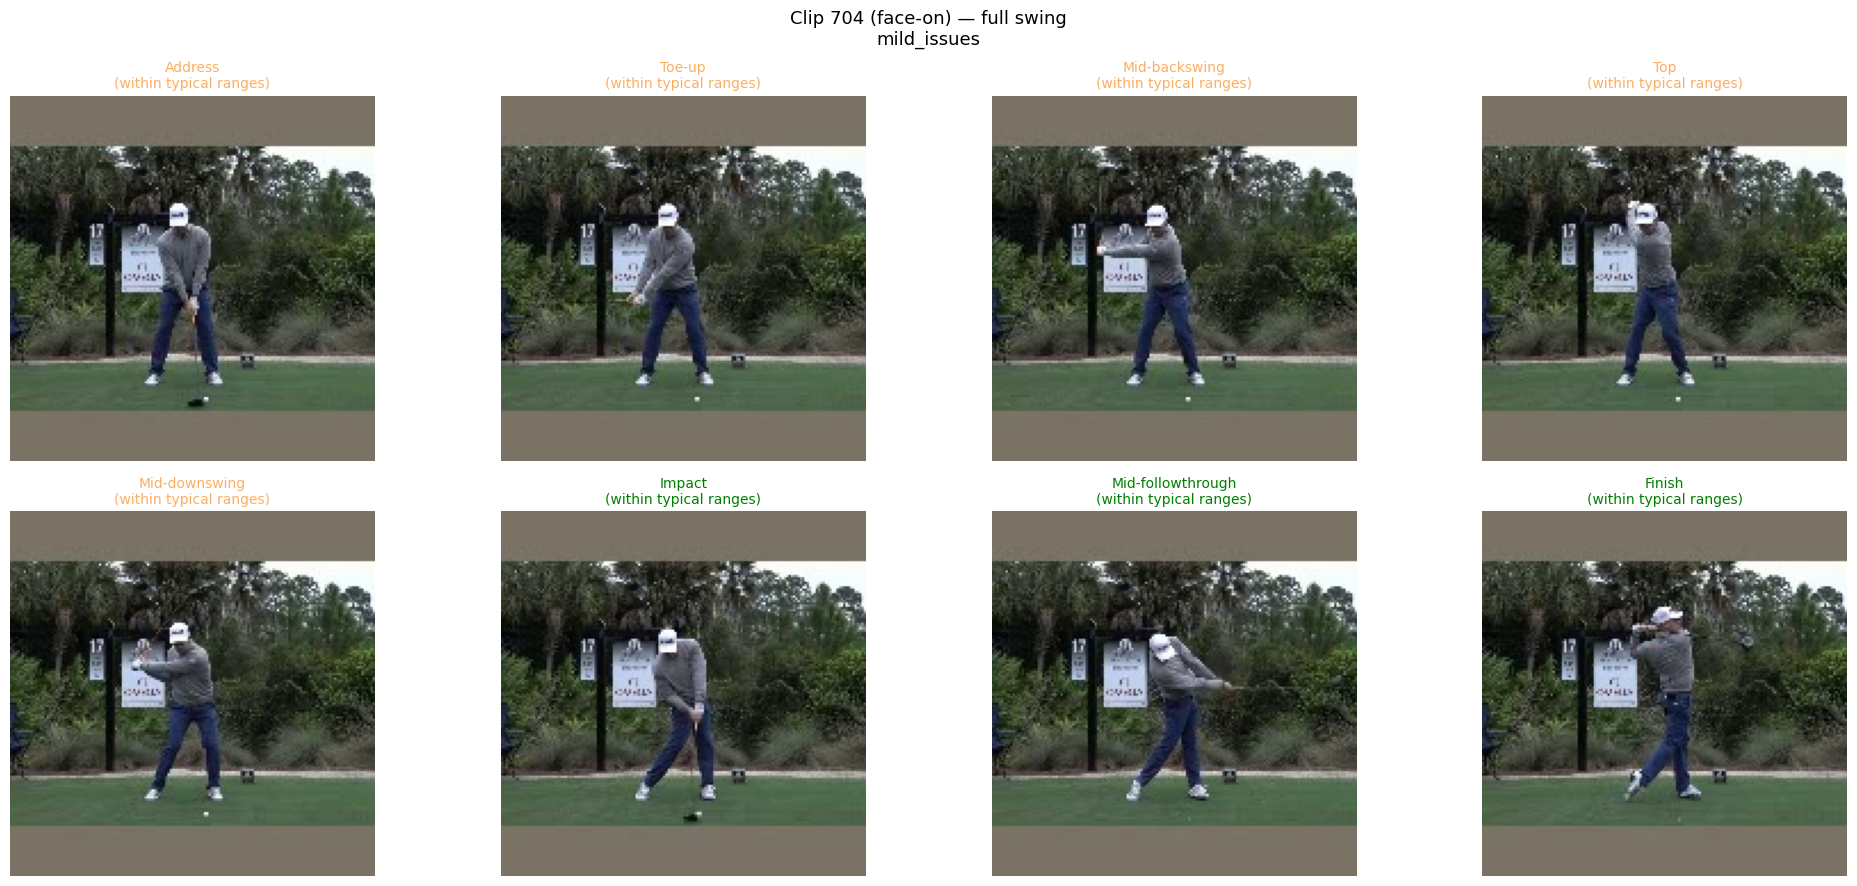

Saved → ..\data\results\agent_demo\full_swing_704_grid.png


In [36]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, frame_data in enumerate(result['per_frame_reports']):
    ax = axes[i]
    img = cv2.imread(str(FRAMES_DIR / frame_data['frame_filename']))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    r = frame_data['report']
    pos = r['p_position']
    sev = r['overall_assessment']
    sev_color = {
        'good': 'green',
        'mild_issues': '#fdae61',
        'notable_issues': '#d7191c',
    }.get(sev, 'gray')
    
    # Top deviation as the title
    if r.get('key_deviations'):
        d = r['key_deviations'][0]
        metric = d.get('metric', '?')
        obs = d.get('observed_value', 0)
        dev_text = f'{metric}: {obs:.0f}° ({d.get("severity", "?")})'
    else:
        dev_text = '(within typical ranges)'
    
    ax.set_title(f'{pos}\n{dev_text}', fontsize=10, color=sev_color)
    ax.axis('off')

plt.suptitle(
    f'Clip {result["clip_id"]} ({result["view"]}) — full swing\n'
    f'{result["synthesis"]["overall_assessment"]}',
    fontsize=13,
)
plt.tight_layout()
vis_path = Path('../data/results/agent_demo') / f'full_swing_{result["clip_id"]}_grid.png'
plt.savefig(vis_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {vis_path}')

# Phase 4f: Test the agent on an external video

Takes a video file (MP4) outside the GolfDB dataset and runs the complete pipeline:
1. Extract every frame and run the CNN to get per-frame probabilities for each P-position
2. Use **argmax with temporal ordering** to identify the 8 canonical event frames
3. Run MediaPipe pose on each event frame
4. Run the full-swing sequential agent (from Phase 4d) to produce two coaching reports: a technical `FullSwingReport` (intermediate/advanced) and a plain-English `BeginnerSwingReport` (entry-level)

### Key design point

The CNN was trained as a single-frame classifier on the 8 GolfDB-annotated event frames. We re-purpose its probability outputs to do event detection on unannotated video - a downstream byproduct of the classifier that doesn't require a separate model.

Temporal ordering enforces that events occur in sequence: Address before Toe-up before Mid-backswing... before Finish. This handles cases where a frame is ambiguous between adjacent positions.

## 1. Configure the video and view

In [57]:
from pathlib import Path

VIDEO_PATH = Path('../data/raw/niels-2.mp4')
VIDEO_VIEW = 'down-the-line' 

EXTERNAL_DIR = Path('../data/results/external_swings') / VIDEO_PATH.stem
EXTERNAL_FRAMES_DIR = EXTERNAL_DIR / 'frames'
EXTERNAL_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

if not VIDEO_PATH.exists():
    raise FileNotFoundError(f'Video not found at {VIDEO_PATH}. Update VIDEO_PATH above.')

print(f'Video: {VIDEO_PATH}')
print(f'View:  {VIDEO_VIEW}')
print(f'Output dir: {EXTERNAL_DIR}')

Video: ..\data\raw\niels-2.mp4
View:  down-the-line
Output dir: ..\data\results\external_swings\niels-2


## 2. Extract frames from the video

In [58]:
import cv2

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
duration_s = n_frames / fps if fps > 0 else 0
print(f'Video: {n_frames} frames @ {fps:.1f} fps = {duration_s:.1f}s, resolution {w}×{h}')

# Extract every frame, save to disk for later access
frame_paths = []
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    out_path = EXTERNAL_FRAMES_DIR / f'frame_{frame_idx:04d}.jpg'
    cv2.imwrite(str(out_path), frame)
    frame_paths.append(out_path)
    frame_idx += 1
cap.release()

print(f'Extracted {len(frame_paths)} frames to {EXTERNAL_FRAMES_DIR}')

Video: 69 frames @ 30.0 fps = 2.3s, resolution 720×1280
Extracted 69 frames to ..\data\results\external_swings\niels-2\frames


## 3 Crop video

Cropping frames to golfer bounding boxes (matches training distribution)...
  Frame 0/69...
  Frame 20/69...
  Frame 40/69...
  Frame 60/69...

Cropped 69/69 frames


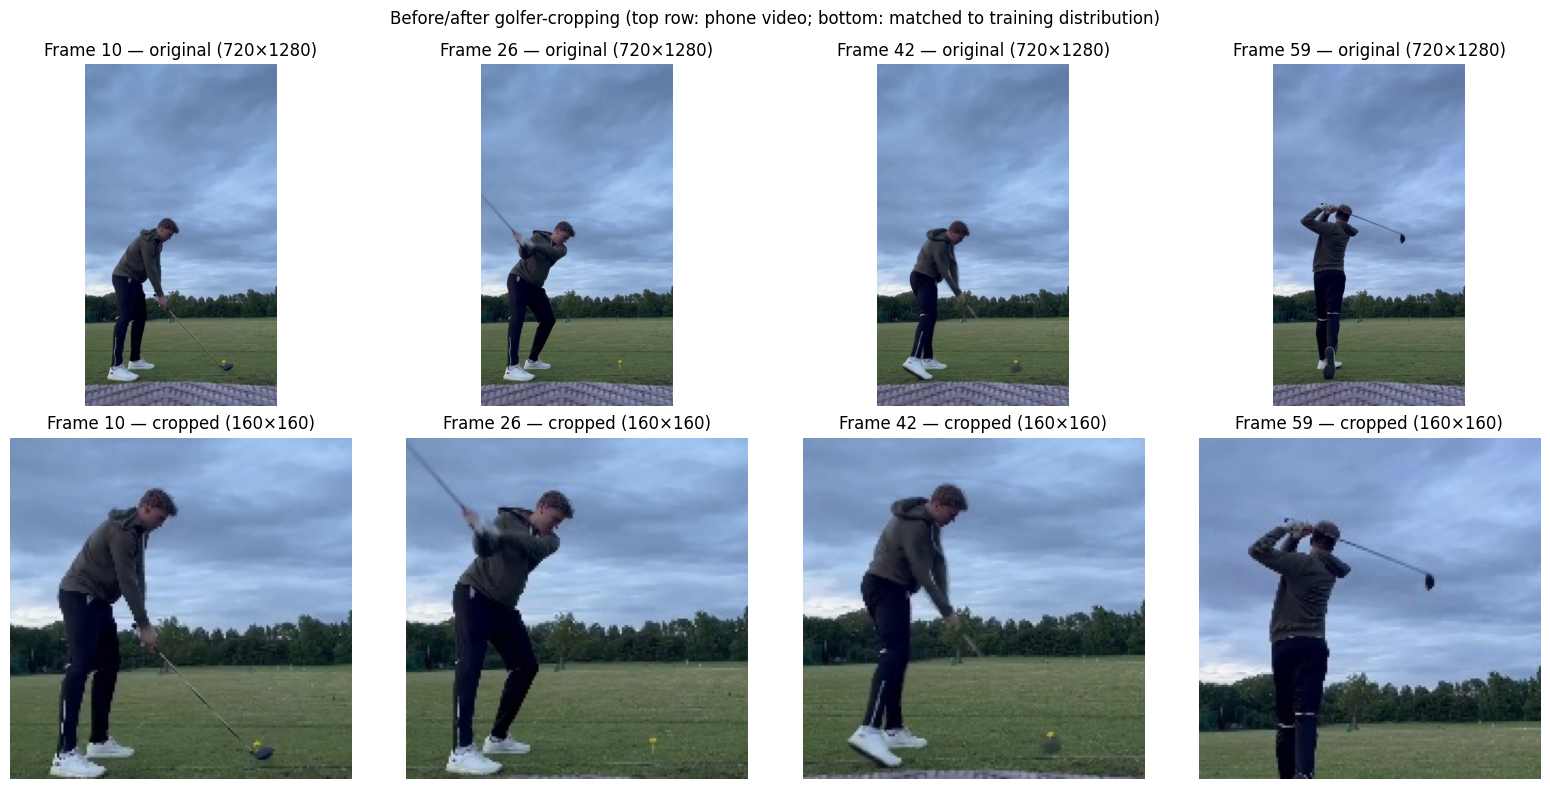

In [59]:
## 24b. Crop frames to match training distribution

import mediapipe as mp
import mediapipe.python.solutions.pose as mp_pose

def compute_golfer_bbox(image_bgr, pose_model, pad_ratio=0.20) -> tuple | None:
    """Detect golfer with MediaPipe, return a square bounding box (x, y, size).
    Returns None if pose detection fails or visibility is too low.
    """
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_bgr.shape[:2]
    results = pose_model.process(rgb)
    
    if results.pose_landmarks is None:
        return None
    
    # Collect visible keypoints in pixel space
    visible_pts = []
    for lm in results.pose_landmarks.landmark:
        if lm.visibility > 0.5:
            visible_pts.append((lm.x * w, lm.y * h))
    
    if len(visible_pts) < 8:  # need a decent number of visible points
        return None
    
    xs = [p[0] for p in visible_pts]
    ys = [p[1] for p in visible_pts]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    
    # Pad
    body_w = x_max - x_min
    body_h = y_max - y_min
    pad_x = body_w * pad_ratio
    pad_y = body_h * pad_ratio
    
    # Add extra padding above the body to capture the club at Top position
    x_min -= pad_x
    x_max += pad_x
    y_min -= pad_y * 1.5  # more padding above for the club
    y_max += pad_y
    
    # Make square (use larger of width/height)
    box_w = x_max - x_min
    box_h = y_max - y_min
    box_size = max(box_w, box_h)
    
    # Center the square box on the body's center
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    half = box_size / 2
    sq_x_min = cx - half
    sq_y_min = cy - half
    
    # Clamp to image bounds
    sq_x_min = max(0, min(int(sq_x_min), w - 1))
    sq_y_min = max(0, min(int(sq_y_min), h - 1))
    sq_size = int(min(box_size, w - sq_x_min, h - sq_y_min))
    
    return (sq_x_min, sq_y_min, sq_size)


def crop_to_golfer(image_bgr, bbox, target_size=160) -> np.ndarray:
    """Crop the image to the bbox and resize to target_size × target_size."""
    x, y, size = bbox
    cropped = image_bgr[y:y+size, x:x+size]
    return cv2.resize(cropped, (target_size, target_size))


# Apply golfer-cropping to all extracted frames
print('Cropping frames to golfer bounding boxes (matches training distribution)...')

CROPPED_FRAMES_DIR = EXTERNAL_DIR / 'frames_cropped'
CROPPED_FRAMES_DIR.mkdir(exist_ok=True)

pose_for_crop = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,  # faster — we just need a rough bbox
    min_detection_confidence=0.5,
)

cropped_paths = []
crop_failures = []
last_good_bbox = None  # for falling back when pose fails

for i, fp in enumerate(frame_paths):
    if i % 20 == 0:
        print(f'  Frame {i}/{len(frame_paths)}...')
    img = cv2.imread(str(fp))
    bbox = compute_golfer_bbox(img, pose_for_crop)
    if bbox is None:
        if last_good_bbox is not None:
            bbox = last_good_bbox  # reuse the last successful detection
        else:
            crop_failures.append(i)
            cropped_paths.append(None)
            continue
    else:
        last_good_bbox = bbox
    
    cropped = crop_to_golfer(img, bbox, target_size=160)
    out_path = CROPPED_FRAMES_DIR / f'frame_{i:04d}.jpg'
    cv2.imwrite(str(out_path), cropped)
    cropped_paths.append(out_path)

pose_for_crop.close()

print(f'\nCropped {sum(1 for p in cropped_paths if p is not None)}/{len(frame_paths)} frames')
if crop_failures:
    print(f'Pose detection failed on {len(crop_failures)} frames (mostly first frames before golfer is visible)')

# Show before/after comparison for a few frames so we can see the cropping worked
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_idxs = np.linspace(10, len(frame_paths) - 10, 4, dtype=int)
for col, idx in enumerate(sample_idxs):
    if cropped_paths[idx] is None:
        continue
    orig = cv2.imread(str(frame_paths[idx]))
    cropped = cv2.imread(str(cropped_paths[idx]))
    axes[0, col].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f'Frame {idx} — original ({orig.shape[1]}×{orig.shape[0]})')
    axes[0, col].axis('off')
    axes[1, col].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'Frame {idx} — cropped (160×160)')
    axes[1, col].axis('off')

plt.suptitle('Before/after golfer-cropping (top row: phone video; bottom: matched to training distribution)')
plt.tight_layout()
plt.savefig(EXTERNAL_DIR / 'crop_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Run the CNN on every frame

For each frame, get the probability distribution over 8 P-positions. We'll use these probabilities for event picking.

In [60]:
import numpy as np
import time

t0 = time.time()
all_probs = []
for i, fp in enumerate(cropped_paths):
    if fp is None:
        # Pose failed earlier — assign uniform probabilities so this frame won't win any argmax
        all_probs.append({label: 1.0 / len(EVENT_NAMES) for label in EVENT_NAMES})
        continue
    if i % 20 == 0:
        print(f'  Frame {i}/{len(cropped_paths)}...')
    result = classify_p_position(fp)
    all_probs.append(result['all_probs'])

# probs_matrix: shape (n_frames, 8) where columns are EVENT_NAMES order
probs_matrix = np.array([
    [p[label] for label in EVENT_NAMES]
    for p in all_probs
])
elapsed = time.time() - t0
print(f'\nClassified {len(cropped_paths)} cropped frames in {elapsed:.1f}s')
print(f'Probability matrix shape: {probs_matrix.shape}')

  Frame 0/69...
  Frame 20/69...
  Frame 40/69...
  Frame 60/69...

Classified 69 cropped frames in 0.9s
Probability matrix shape: (69, 8)


## 5. Visualize per-position probabilities across the video

Each P-position's probability over time.

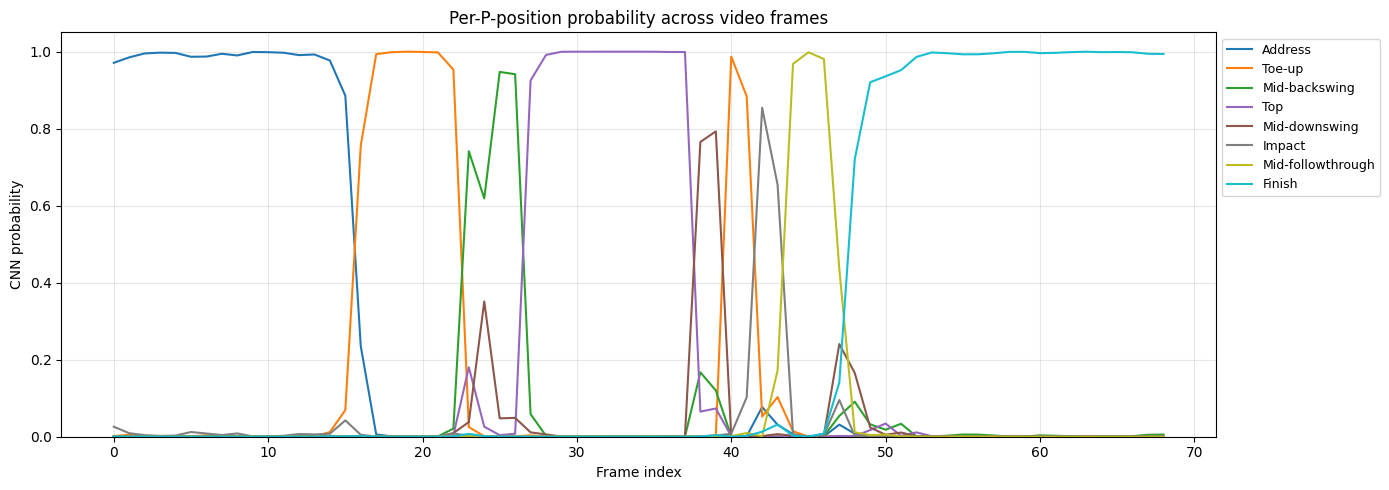

Saved → ..\data\results\external_swings\niels-2\probability_curves.png


In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(EVENT_NAMES)))
for i, label in enumerate(EVENT_NAMES):
    ax.plot(probs_matrix[:, i], label=label, color=colors[i], linewidth=1.5)

ax.set_xlabel('Frame index')
ax.set_ylabel('CNN probability')
ax.set_title('Per-P-position probability across video frames')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EXTERNAL_DIR / 'probability_curves.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {EXTERNAL_DIR / "probability_curves.png"}')

## 6. Pick events with argmax + temporal ordering

Constraint: events must occur in order (Address < Toe-up < Mid-backswing < ... < Finish). Within the available frame window for each event, we pick the frame with the highest probability for that event.

In [62]:
def pick_events_temporal_argmax(probs: np.ndarray, event_names: list[str]) -> dict:
    """For each event in order, pick the frame index with the highest probability,
    constrained to be after the previous event's pick.
    
    Returns a dict mapping event_name → chosen frame index.
    """
    n_frames = probs.shape[0]
    n_events = len(event_names)
    picks = {}
    last_idx = -1
    
    for i, label in enumerate(event_names):
        # Must be after previous event AND leave room for remaining events
        n_remaining = n_events - i - 1
        start = last_idx + 1
        end = n_frames - n_remaining  # leave room for the rest
        
        if start >= end:
            # Not enough frames left — fall back to last_idx + 1
            picks[label] = min(last_idx + 1, n_frames - 1)
        else:
            window_probs = probs[start:end, i]
            local_argmax = int(np.argmax(window_probs))
            picks[label] = start + local_argmax
        
        last_idx = picks[label]
    
    return picks


event_frame_idx = pick_events_temporal_argmax(probs_matrix, EVENT_NAMES)

print('Event frame picks (with temporal ordering):')
for label, idx in event_frame_idx.items():
    confidence = probs_matrix[idx, EVENT_NAMES.index(label)]
    print(f'  {label:20s} → frame {idx:3d}  (CNN confidence {confidence:.3f})')

Event frame picks (with temporal ordering):
  Address              → frame   9  (CNN confidence 0.999)
  Toe-up               → frame  19  (CNN confidence 1.000)
  Mid-backswing        → frame  25  (CNN confidence 0.947)
  Top                  → frame  32  (CNN confidence 1.000)
  Mid-downswing        → frame  39  (CNN confidence 0.793)
  Impact               → frame  42  (CNN confidence 0.854)
  Mid-followthrough    → frame  45  (CNN confidence 0.998)
  Finish               → frame  63  (CNN confidence 1.000)


## 7. Verify picks visually

Show the 8 picked frames in order.

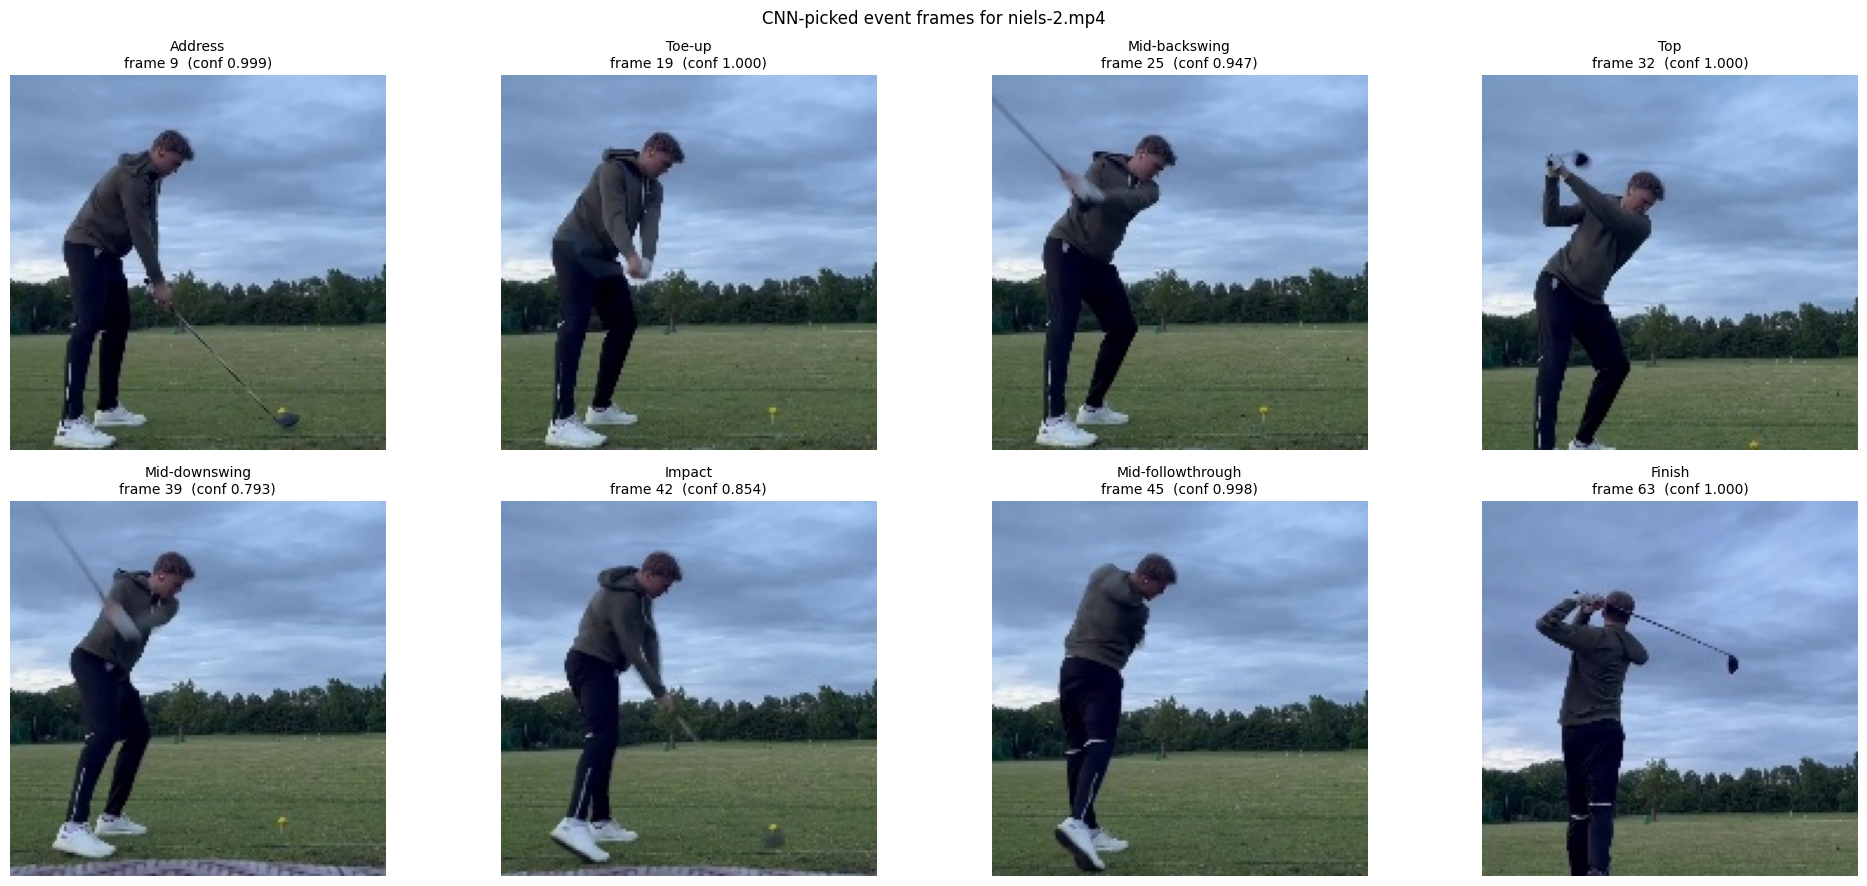

Saved → ..\data\results\external_swings\niels-2\event_picks.png


In [63]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for ax, (label, idx) in zip(axes, event_frame_idx.items()):
    img = cv2.imread(str(cropped_paths[idx]))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    confidence = probs_matrix[idx, EVENT_NAMES.index(label)]
    ax.set_title(f'{label}\nframe {idx}  (conf {confidence:.3f})', fontsize=10)
    ax.axis('off')

plt.suptitle(f'CNN-picked event frames for {VIDEO_PATH.name}', fontsize=12)
plt.tight_layout()
plt.savefig(EXTERNAL_DIR / 'event_picks.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {EXTERNAL_DIR / "event_picks.png"}')

## 8. Build a synthetic clip for the agent

The full-swing agent expects clip data in the same shape as `df_kp` rows. Build that structure from our picked event frames.

In [64]:
EVENT_FRAMES_DIR = EXTERNAL_DIR / 'event_frames'
EVENT_FRAMES_DIR.mkdir(exist_ok=True)

external_clip_id = 99999  # synthetic ID for the external swing
external_rows = []

for event_idx, label in enumerate(EVENT_NAMES, start=1):
    src_frame_idx = event_frame_idx[label]
    src_path = cropped_paths[src_frame_idx]   # ← changed from frame_paths
    if src_path is None:
        # Fall back to nearest non-failed cropped frame
        for offset in range(1, 10):
            if src_frame_idx - offset >= 0 and cropped_paths[src_frame_idx - offset] is not None:
                src_path = cropped_paths[src_frame_idx - offset]
                break
            if src_frame_idx + offset < len(cropped_paths) and cropped_paths[src_frame_idx + offset] is not None:
                src_path = cropped_paths[src_frame_idx + offset]
                break
    
    canonical_name = f'external_clip{external_clip_id}_event{event_idx}.jpg'
    dst_path = EVENT_FRAMES_DIR / canonical_name
    img = cv2.imread(str(src_path))
    cv2.imwrite(str(dst_path), img)
    
    external_rows.append({
        'clip_id': external_clip_id,
        'view': VIDEO_VIEW,
        'event_idx': event_idx,
        'label': label,
        'frame_filename': canonical_name,
    })

# Build a tiny DataFrame that mimics df_kp's structure for the rows we need
import pandas as pd
df_external = pd.DataFrame(external_rows)
print(f'Built {len(df_external)} synthetic clip rows for external swing.')
print(df_external)

Built 8 synthetic clip rows for external swing.
   clip_id           view  event_idx              label  \
0    99999  down-the-line          1            Address   
1    99999  down-the-line          2             Toe-up   
2    99999  down-the-line          3      Mid-backswing   
3    99999  down-the-line          4                Top   
4    99999  down-the-line          5      Mid-downswing   
5    99999  down-the-line          6             Impact   
6    99999  down-the-line          7  Mid-followthrough   
7    99999  down-the-line          8             Finish   

                  frame_filename  
0  external_clip99999_event1.jpg  
1  external_clip99999_event2.jpg  
2  external_clip99999_event3.jpg  
3  external_clip99999_event4.jpg  
4  external_clip99999_event5.jpg  
5  external_clip99999_event6.jpg  
6  external_clip99999_event7.jpg  
7  external_clip99999_event8.jpg  


## 9. Run the full-swing agent on the external swing

Reuse `analyze_full_swing` but with a custom frame directory and the external rows.

In [65]:
import time
import json


async def analyze_external_swing(
    df_clip: pd.DataFrame,
    frames_dir: Path,
    save_to: Path = None,
) -> dict:
    """Variant of analyze_full_swing that takes an external swing's frames."""
    t_start = time.time()
    
    df_clip = df_clip.sort_values('event_idx')
    if len(df_clip) != 8:
        raise ValueError(f'Expected 8 frames, got {len(df_clip)}')
    
    view = df_clip.iloc[0]['view']
    clip_id = int(df_clip.iloc[0]['clip_id'])
    print(f'Analyzing external clip {clip_id} ({view}, 8 frames)...')
    
    per_frame_reports = []
    classifier_disagreements = []
    
    for _, row in df_clip.iterrows():
        image_path = str(frames_dir / row['frame_filename'])
        true_label = row['label']
        
        print(f'  [{row["event_idx"]}/8] {true_label}...', end=' ', flush=True)
        t_frame = time.time()
        
        entry = await analyze_one_frame_with_context(
            image_path=image_path,
            view=view,
            prior_reports=per_frame_reports,
        )
        
        predicted = entry['report']['p_position']
        if predicted != true_label:
            classifier_disagreements.append(
                f'event {row["event_idx"]} (assumed: {true_label}, predicted: {predicted})'
            )
        
        entry['frame_filename'] = row['frame_filename']
        entry['true_label'] = true_label
        entry['event_idx'] = int(row['event_idx'])
        per_frame_reports.append(entry)
        
        print(f'done in {time.time() - t_frame:.1f}s')
    
    print(f'  [synth] Synthesizing FullSwingReport...', end=' ', flush=True)
    t_synth = time.time()
    synthesis = await synthesize_full_swing(
        clip_id=clip_id,
        per_frame_reports=per_frame_reports,
        classifier_disagreements=classifier_disagreements,
    )
    print(f'done in {time.time() - t_synth:.1f}s')

    print(f'  [beginner] Generating beginner report...', end=' ', flush=True)
    t_beg = time.time()
    beginner = await synthesize_beginner_report(synthesis)
    print(f'done in {time.time() - t_beg:.1f}s')

    wall_time = time.time() - t_start
    
    out = {
        'clip_id': clip_id,
        'view': view,
        'source': str(VIDEO_PATH),
        'per_frame_reports': [
            {
                'event_idx': e['event_idx'],
                'frame_filename': e['frame_filename'],
                'true_label': e['true_label'],
                'report': e['report'],
            }
            for e in per_frame_reports
        ],
        'synthesis': synthesis.model_dump(),
        'beginner_report': beginner.model_dump(),
        'classifier_disagreements': classifier_disagreements,
        'wall_time_sec': round(wall_time, 1),
    }
    
    if save_to:
        save_to.parent.mkdir(parents=True, exist_ok=True)
        with open(save_to, 'w') as f:
            json.dump(out, f, indent=2)
        print(f'  Saved to {save_to}')
        beg_path = save_to.parent / 'beginner_swing_report.json'
        with open(beg_path, 'w') as f:
            json.dump(beginner.model_dump(), f, indent=2)
        print(f'  Saved beginner report to {beg_path}')
    
    print(f'Total: {wall_time:.1f}s, {len(classifier_disagreements)} classifier disagreements')
    return out


result_external = await analyze_external_swing(
    df_external,
    frames_dir=EVENT_FRAMES_DIR,
    save_to=EXTERNAL_DIR / 'full_swing_report.json',
)

Analyzing external clip 99999 (down-the-line, 8 frames)...
  [1/8] Address... 

C:\Users\Jacob\AppData\Roaming\Python\Python312\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


done in 25.0s
  [2/8] Toe-up... done in 23.0s
  [3/8] Mid-backswing... done in 28.5s
  [4/8] Top... done in 20.4s
  [5/8] Mid-downswing... done in 25.4s
  [6/8] Impact... done in 22.5s
  [7/8] Mid-followthrough... done in 16.3s
  [8/8] Finish... done in 22.7s
  [synth] Synthesizing FullSwingReport... done in 26.6s
  [beginner] Generating beginner report... done in 11.9s
  Saved to ..\data\results\external_swings\niels-2\full_swing_report.json
  Saved beginner report to ..\data\results\external_swings\niels-2\beginner_swing_report.json
Total: 222.5s, 0 classifier disagreements


## 10. Show the result

EXTERNAL SWING REPORT — niels-2.mp4
Overall: notable_issues

Headline:
  Setup shows a clear shoulder‑alignment fault at address that was not fully corrected through the swing, resulting in a collapsed/under‑rotated follow‑through and mild finish clearance. The downswing sequence and mid‑downswing position look functional, so correcting setup alignment and committing to rotation through impact should produce the largest, quickest gains. Start with a simple address alignment check and pair it with finish‑focused drills to train a connected release.

Priority issues (1):

  1. Shoulder alignment / incomplete shoulder rotation (collapsed follow‑through) [notable]
     Affects: Address, Top, Impact, Mid-followthrough, Finish
     A substantially off shoulder line at Address (notable) appears related to an under‑rotated/collapsed shoulder line in the mid‑followthrough (notable). The classifier frames show the shoulders not square at setup and then not rotating fully through the target — pro

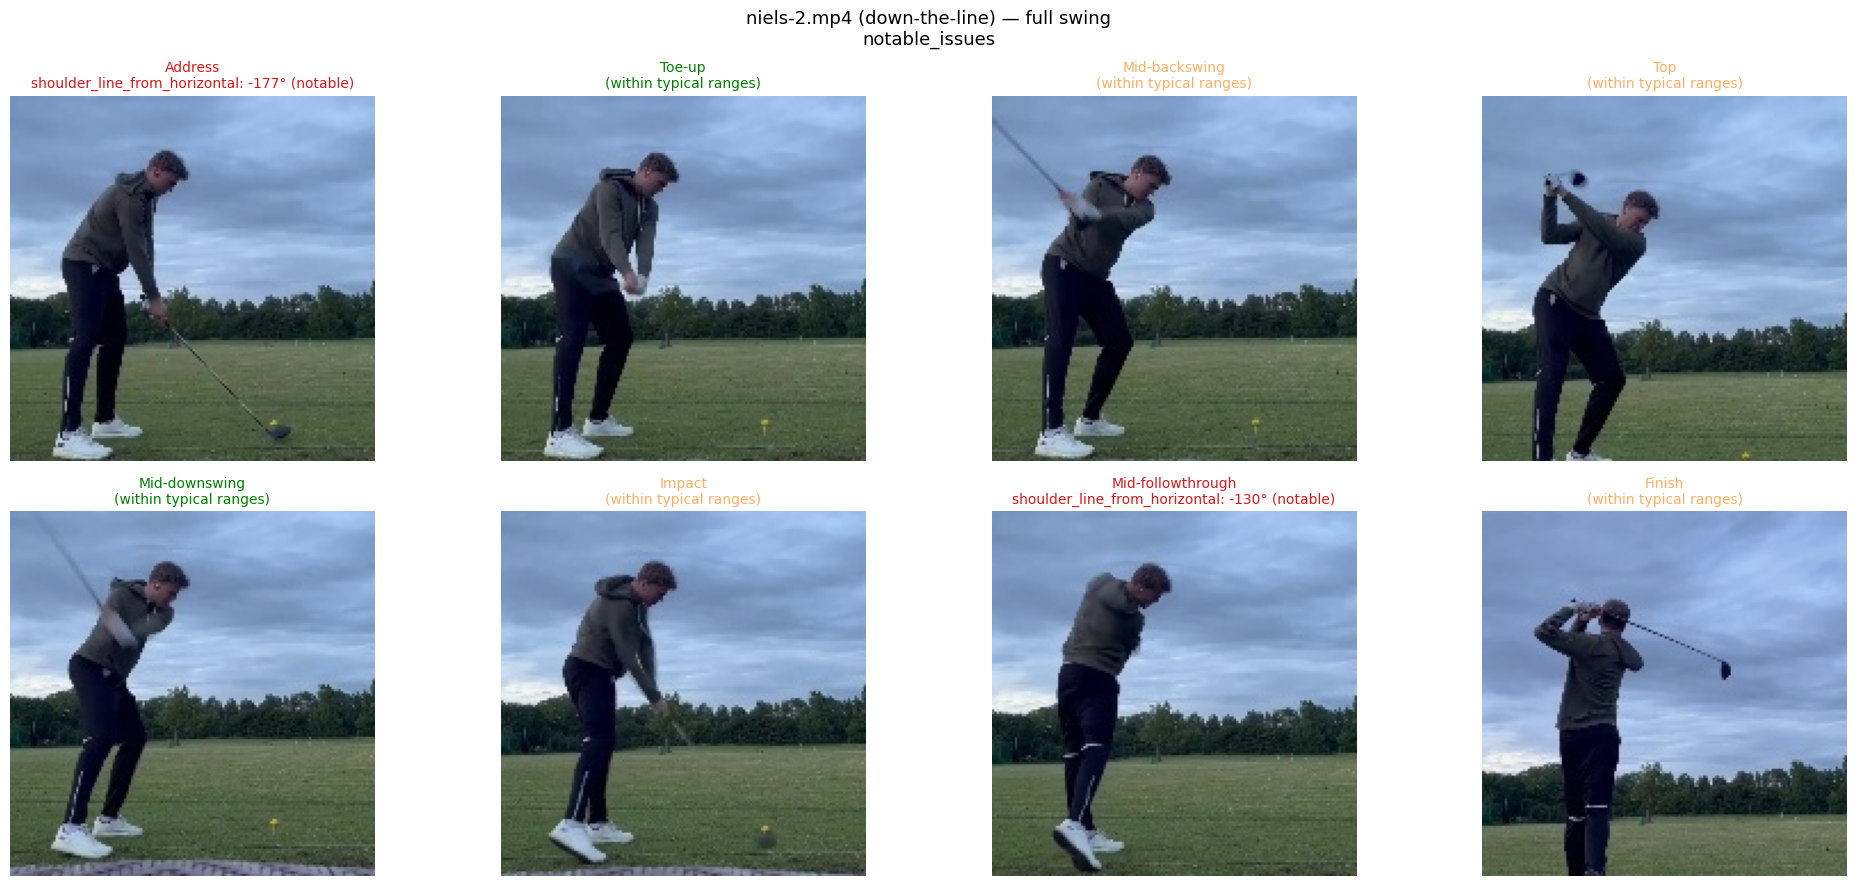

Saved → ..\data\results\external_swings\niels-2\full_swing_grid.png


In [66]:
synth = result_external['synthesis']
print('=' * 70)
print(f'EXTERNAL SWING REPORT — {VIDEO_PATH.name}')
print('=' * 70)
print(f'Overall: {synth["overall_assessment"]}')
print(f'\nHeadline:')
print(f'  {synth["headline_summary"]}')

if synth['priority_issues']:
    print(f'\nPriority issues ({len(synth["priority_issues"])}):')
    for i, issue in enumerate(synth['priority_issues'], 1):
        print(f'\n  {i}. {issue["issue_name"]} [{issue["severity"]}]')
        print(f'     Affects: {", ".join(issue["affected_positions"])}')
        print(f'     {issue["explanation"]}')
        print(f'     → {issue["primary_recommendation"]}')
else:
    print(f'\nNo priority issues identified.')

if synth.get('propagation_observations'):
    print(f'\nPropagation patterns:')
    for p in synth['propagation_observations']:
        print(f'  • {p}')

print(f'\nPer-position breakdown:')
for pos, summary in synth['per_position_summary'].items():
    print(f'  {pos:20s} — {summary}')

if synth.get('classifier_disagreements'):
    print(f'\nClassifier disagreements: {synth["classifier_disagreements"]}')

print(f'\nWall time: {result_external["wall_time_sec"]}s')

br = result_external.get('beginner_report', {})
print('\n' + '=' * 70)
print('  BEGINNER REPORT (entry-level audience)')
print('=' * 70)
print('What you\'re doing well:')
print(f'  {br.get("encouragement", "")}')
print('\nTop 3 things to work on:')
for i, t in enumerate(br.get('top_3_takeaways', []), 1):
    print(f'\n  {i}. {t["title"]}')
    print(f'     Feel: {t["feel_cue"]}')
    print(f'     Drill: {t["simple_drill"]}')
print(f'\nIn one sentence: {br.get("one_sentence_summary", "")}')

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, frame_data in enumerate(result_external['per_frame_reports']):
    ax = axes[i]
    img = cv2.imread(str(EVENT_FRAMES_DIR / frame_data['frame_filename']))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    r = frame_data['report']
    pos = r['p_position']
    sev = r['overall_assessment']
    sev_color = {
        'good': 'green',
        'mild_issues': '#fdae61',
        'notable_issues': '#d7191c',
    }.get(sev, 'gray')
    if r.get('key_deviations'):
        d = r['key_deviations'][0]
        dev_text = f'{d.get("metric", "?")}: {d.get("observed_value", 0):.0f}° ({d.get("severity", "?")})'
    else:
        dev_text = '(within typical ranges)'
    ax.set_title(f'{pos}\n{dev_text}', fontsize=10, color=sev_color)
    ax.axis('off')

plt.suptitle(
    f'{VIDEO_PATH.name} ({VIDEO_VIEW}) — full swing\n'
    f'{synth["overall_assessment"]}',
    fontsize=13,
)
plt.tight_layout()
plt.savefig(EXTERNAL_DIR / 'full_swing_grid.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved → {EXTERNAL_DIR / "full_swing_grid.png"}')